# visium HD -> three groups

In [21]:
import scanpy as sc
import anndata as ad
import os
import pandas as pd
import numpy as np
import singlecellexperiment as sce
import celldex
import singler
from scipy import sparse as sp
import multiprocessing

# --- CONFIGURATION ---
VISIUM_HD_PATH = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung7/sample1/outs/binned_outputs/square_008um/filtered_feature_bc_matrix"
SPATIAL_DIR    = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung7/sample1/outs/binned_outputs/square_008um/spatial"
OUT_DIR        = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung7/sample1/modified_pipeline_results1"
os.makedirs(OUT_DIR, exist_ok=True)

sample_id = "lung7_sample1_square008um"
THREADS = 32 # Set to 32 as requested

# --- DATA LOADING & QC ---
sample_adata = sc.read_10x_mtx(VISIUM_HD_PATH, var_names="gene_symbols", cache=False)
sample_adata.var_names_make_unique()
sc.pp.filter_genes(sample_adata, min_cells=1)

# Tissue filtering
pos_path = os.path.join(SPATIAL_DIR, "tissue_positions.parquet")
if os.path.exists(pos_path):
    pos = pd.read_parquet(pos_path)
    if "barcode" in pos.columns:
        pos = pos.set_index("barcode")
    common = pos.index.intersection(sample_adata.obs_names)
    sample_adata = sample_adata[common].copy()
    pos = pos.loc[common]
    sample_adata.obs["in_tissue"] = pos["in_tissue"].astype(int).values
    sample_adata = sample_adata[sample_adata.obs["in_tissue"] == 1].copy()

# QC Metrics
sample_adata.var["mt"] = sample_adata.var_names.str.startswith("MT-")
sample_adata.var["ribo"] = sample_adata.var_names.str.startswith(("RPS", "RPL"))
sample_adata.var["hb"] = sample_adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(sample_adata, qc_vars=["mt", "ribo", "hb"], percent_top=[20], inplace=True, log1p=True)
sample_adata = sample_adata[sample_adata.obs.pct_counts_mt <= 20]
sc.pp.filter_cells(sample_adata, min_genes=100) #500 genes was overkill and barely outputted anything (basically that looks for stacked bins), 50 genes was too generous and there WAY too many cells (especially in stromal, we dont want overfitting)
sc.pp.filter_genes(sample_adata, min_cells=3)

# --- ANNOTATION WITH SINGLER ---
# Convert to SCE for SingleR
sce_obj = sce.SingleCellExperiment.from_anndata(sample_adata)
counts_mat = sce_obj.assay("X")
if sp.issparse(counts_mat):
    counts_mat = counts_mat.tocsr()
    counts_mat.sort_indices()
genes = list(sce_obj.row_data.row_names)

ref_data = celldex.fetch_reference(name="blueprint_encode", version="2024-02-26", realize_assays=True)
ref_labels = list(ref_data.get_column_data().column("label.main"))

print(f"Running SingleR annotation on {sample_adata.n_obs} bins using {THREADS} threads...")

results = singler.annotate_single(
    test_data     = counts_mat,
    test_features = genes,
    ref_data      = ref_data,
    ref_labels    = ref_labels,
    num_threads   = THREADS
)

sample_adata.obs["cell_type"] = results.column("best")

# --- CATEGORICAL EXTRACTION & SUMMARY ---

cell_groups = {
    "IMMUNE": [
        "T cells", "B cells", "NK cells", "Monocytes", "Macrophages", 
        "Dendritic cells", "Mast cells", "Neutrophils",
        "B-cells", "DC", "CD4+ T-cells", "CD8+ T-cells", 
        "Eosinophils", "HSC", "Erythrocytes"
    ],
    "EPITHELIAL": [
        "Epithelial cells", "AT1 / AT2", "Basal cells", 
        "Secretory cells", "Tumor epithelial", "Club cells",
        "Keratinocytes", "Melanocytes"
    ],
    "STROMAL": [
        "Fibroblasts", "Endothelial cells", "Pericytes", 
        "Smooth muscle cells", "Mesenchymal stromal cells",
        "Adipocytes", "Skeletal muscle", "Mesangial cells", 
        "Smooth muscle", "Chondrocytes", "Myocytes"
    ]
}

# Tag broad categories
sample_adata.obs['broad_category'] = 'Other'
for category, cell_list in cell_groups.items():
    sample_adata.obs.loc[sample_adata.obs['cell_type'].isin(cell_list), 'broad_category'] = category

# Summary loop
summary_data = []
print("\n--- Saving Categories & Generating Summary ---")

for group_name in cell_groups.keys():
    subset = sample_adata[sample_adata.obs['broad_category'] == group_name].copy()
    count = subset.n_obs
    pct = (count / sample_adata.n_obs) * 100
    summary_data.append({"Category": group_name, "Count": count, "Percentage": f"{pct:.2f}%"})
    
    if count > 0:
        out_path = os.path.join(OUT_DIR, f"adata_{sample_id}_{group_name.lower()}.h5ad")
        subset.write(out_path)
        print(f"Saved {group_name} to {out_path}")

# Add unassigned to table
other_count = (sample_adata.obs['broad_category'] == 'Other').sum()
summary_data.append({"Category": "OTHER", "Count": other_count, "Percentage": f"{(other_count/sample_adata.n_obs)*100:.2f}%"})

print("\n--- Final Statistics ---")
print(pd.DataFrame(summary_data).to_string(index=False))

/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:140: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Running SingleR annotation on 145 bins using 32 threads...

--- Saving Categories & Generating Summary ---
Saved IMMUNE to /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung7/sample1/modified_pipeline_results1/adata_lung7_sample1_square008um_immune.h5ad
Saved EPITHELIAL to /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung7/sample1/modified_pipeline_results1/adata_lung7_sample1_square008um_epithelial.h5ad
Saved STROMAL to /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung7/sample1/modified_pipeline_results1/adata_lung7_sample1_square008um_stromal.h5ad

--- Final Statistics ---
  Category  Count Percentage
    IMMUNE     54     37.24%
EPITHELIAL     23     15.86%
   STROMAL     63     43.45%
     OTHER      5      3.45%


In [18]:
import scanpy as sc
import pandas as pd
from pathlib import Path

# --- CONFIG ---
# Update these to the folders containing your h5ad files
OLD_DIR = Path("/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung3/sample1/modified_pipeline_results")
NEW_DIR = Path("/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung3/sample1/modified_pipeline_results1")

# List the categories to compare
categories = ["immune", "epithelial", "stromal"]

comparison_rows = []

print(f"{'Category':<15} | {'Old Count':<10} | {'New Count':<10} | {'Increase':<10} | {'% Change':<10}")
print("-" * 65)

for cat in categories:
    # Use glob to find the files regardless of the exact prefix/sample name
    old_file = list(OLD_DIR.glob(f"*{cat}.h5ad"))
    new_file = list(NEW_DIR.glob(f"*{cat}.h5ad"))
    
    if old_file and new_file:
        # Load metadata only (header) to speed this up
        adata_old = sc.read_h5ad(old_file[0], backed='r')
        adata_new = sc.read_h5ad(new_file[0], backed='r')
        
        old_count = adata_old.n_obs
        new_count = adata_new.n_obs
        diff = new_count - old_count
        pct_change = (diff / old_count) * 100 if old_count > 0 else 0
        
        comparison_rows.append({
            "Category": cat.upper(),
            "Old_Count": old_count,
            "New_Count": new_count,
            "Diff": diff,
            "Pct_Change": pct_change
        })
        
        print(f"{cat.upper():<15} | {old_count:<10} | {new_count:<10} | {diff:<10} | {pct_change:>8.2f}%")
    else:
        print(f"SKIPPING {cat.upper()}: File not found in one of the directories.")

# Summary Logic
total_old = sum(r['Old_Count'] for r in comparison_rows)
total_new = sum(r['New_Count'] for r in comparison_rows)
total_diff = total_new - total_old

print("-" * 65)
print(f"{'TOTAL':<15} | {total_old:<10} | {total_new:<10} | {total_diff:<10} | {(total_diff/total_old)*100:>8.2f}%")

Category        | Old Count  | New Count  | Increase   | % Change  
-----------------------------------------------------------------
IMMUNE          | 100657     | 111305     | 10648      |    10.58%
EPITHELIAL      | 45878      | 47045      | 1167       |     2.54%
STROMAL         | 93743      | 103165     | 9422       |    10.05%
-----------------------------------------------------------------
TOTAL           | 240278     | 261515     | 21237      |     8.84%


In [ ]:
print(sample_adata[sample_adata.obs['broad_category'] == 'OTHER'].obs['cell_type'].value_counts().head(20))

Series([], Name: cell_type, dtype: int64)


# scRNAseq -> three groups

In [ ]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import singlecellexperiment as sce
import singler
import celldex
from pathlib import Path
from scipy import sparse as sp

# =============================================================================
# !!! EDIT THESE 4 LINES FOR EACH DATASET !!!
# =============================================================================
INPUT_PATH  = "/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung3/GSM3304011_P3_Tumor_processed_data.txt"
SAMPLE_ID   = "lung1sample3"
FILE_TYPE   = "dense_txt" # "dense_txt", "dense_tsv", "dense_csv", "standard_10x", or "custom_10x"
BASE_OUTPUT = Path("/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung2/modified_qc/")

# Create output structure
TRIPARTITE_DIR = BASE_OUTPUT / "tripartite_results"
TRIPARTITE_DIR.mkdir(parents=True, exist_ok=True)

THREADS = 32

# =============================================================================
# 1. FLEXIBLE LOAD LOGIC
# =============================================================================
def load_data(path_str, fmt):
    path = Path(path_str)
    print(f"[{SAMPLE_ID}] Loading {fmt} from: {path.name}...")
    try:
        if fmt == "dense_txt":
            curr_adata = sc.read_text(path, delimiter='\t').T
        elif fmt == "dense_csv":
            curr_adata = sc.read_csv(path)
        elif fmt == "dense_tsv":
            df = pd.read_csv(path, sep='\t', index_col=0)
            curr_adata = ad.AnnData(df.T)
        elif fmt == "standard_10x":
            curr_adata = sc.read_10x_mtx(path, var_names='gene_symbols', cache=True)
        elif fmt == "custom_10x":
            mtx_files = list(path.glob("*matrix*.mtx*"))
            if not mtx_files: 
                available = [f.name for f in path.glob("*")]
                raise FileNotFoundError(f"No .mtx found. Folder contains: {available}")
            print(f"   -> Found matrix: {mtx_files[0].name}")
            curr_adata = sc.read_mtx(mtx_files[0]).T
            feat_files = list(path.glob("*features*.tsv*")) or list(path.glob("*genes*.tsv*"))
            if feat_files:
                print(f"   -> Found features: {feat_files[0].name}")
                genes = pd.read_csv(feat_files[0], sep='\t', header=None)
                curr_adata.var_names = genes[1].values if genes.shape[1] > 1 else genes[0].values
            bar_files = list(path.glob("*barcodes*.tsv*"))
            if bar_files:
                print(f"   -> Found barcodes: {bar_files[0].name}")
                barcodes = pd.read_csv(bar_files[0], sep='\t', header=None)
                curr_adata.obs_names = barcodes[0].values
        else:
            raise ValueError("Invalid FILE_TYPE")
        curr_adata.var_names_make_unique()
        curr_adata.obs_names_make_unique()
        return curr_adata
    except Exception as e:
        print(f"ERROR LOADING DATA: {str(e)}")
        return None

# =============================================================================
# 2. QC & PREPROCESSING
# =============================================================================
adata = load_data(INPUT_PATH, FILE_TYPE)
if adata is None: exit()

print(f"   -> Initial shape: {adata.shape}")

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
hvg_list = adata.var_names[adata.var['highly_variable']].tolist()

# =============================================================================
# 3. SINGLER ANNOTATION (Corrected for Python Wrapper)
# =============================================================================
print("Fetching Blueprint+Encode Reference...")
ref_data = celldex.fetch_reference("blueprint_encode", "2024-02-26", realize_assays=True)
ref_labels = list(ref_data.get_column_data().column("label.main"))

# Convert to SingleCellExperiment
sce_obj = sce.SingleCellExperiment.from_anndata(adata)
all_genes = [str(x) for x in sce_obj.row_data.row_names]

# Get indices for HVGs to subset the matrix manually
hvg_indices = [i for i, gene in enumerate(all_genes) if gene in hvg_list]
subset_genes = [all_genes[i] for i in hvg_indices]

counts_mat = sce_obj.assay("X")
if sp.issparse(counts_mat):
    counts_mat = counts_mat.tocsr()

# Subset the matrix to only include HVGs
counts_mat_subset = counts_mat[hvg_indices, :]

print(f"Running SingleR on {adata.n_obs} cells using {len(subset_genes)} HVGs...")
results = singler.annotate_single(
    test_data=counts_mat_subset,
    test_features=subset_genes,
    ref_data=ref_data,
    ref_labels=ref_labels,
    num_threads=THREADS
)
adata.obs["cell_type_singler"] = list(map(str, results.column("best")))

# =============================================================================
# 4. TRIPARTITE EXTRACTION
# =============================================================================
cell_groups = {
    "IMMUNE": [
        "T cells", "B cells", "NK cells", "Monocytes", "Macrophages", 
        "Dendritic cells", "Mast cells", "Neutrophils",
        "B-cells", "DC", "CD4+ T-cells", "CD8+ T-cells", 
        "Eosinophils", "HSC", "Erythrocytes"
    ],
    "EPITHELIAL": [
        "Epithelial cells", "AT1 / AT2", "Basal cells", 
        "Secretory cells", "Tumor epithelial", "Club cells",
        "Keratinocytes", "Melanocytes"
    ],
    "STROMAL": [
        "Fibroblasts", "Endothelial cells", "Pericytes", 
        "Smooth muscle cells", "Mesenchymal stromal cells",
        "Adipocytes", "Skeletal muscle", "Mesangial cells", 
        "Smooth muscle", "Chondrocytes", "Myocytes"
    ]
}

adata.obs['broad_category'] = 'Other'
for category, cell_list in cell_groups.items():
    adata.obs.loc[adata.obs['cell_type_singler'].isin(cell_list), 'broad_category'] = category

summary_data = []
for group_name in cell_groups.keys():
    subset = adata[adata.obs['broad_category'] == group_name].copy()
    count = subset.n_obs
    pct = (count / adata.n_obs) * 100
    summary_data.append({"Category": group_name, "Count": count, "Percentage": f"{pct:.2f}%"})
    
    if count > 0:
        out_path = TRIPARTITE_DIR / f"{SAMPLE_ID}_{group_name.lower()}.h5ad"
        subset.write(out_path, compression="lzf")

# Add Other to summary
other_count = (adata.obs['broad_category'] == 'Other').sum()
summary_data.append({"Category": "OTHER", "Count": other_count, "Percentage": f"{(other_count/adata.n_obs)*100:.2f}%"})

print("\n--- Final Statistics ---")
print(pd.DataFrame(summary_data).to_string(index=False))

# If "Other" is high, print the top labels to see what we missed
if other_count > (adata.n_obs * 0.05):
    print("\n--- High 'Other' count detected. Top labels: ---")
    print(adata.obs.loc[adata.obs['broad_category'] == 'Other', 'cell_type_singler'].value_counts().head(10))

[lung1sample3] Loading dense_txt from: GSM3304011_P3_Tumor_processed_data.txt...
   -> Initial shape: (328, 3212)
Fetching Blueprint+Encode Reference...
Running SingleR on 307 cells using 2000 HVGs...

--- Final Statistics ---
  Category  Count Percentage
    IMMUNE    115     37.46%
EPITHELIAL    188     61.24%
   STROMAL      4      1.30%
     OTHER      0      0.00%


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

# Load the dataset
adata = sc.read_h5ad('/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung_reimagined/immune/lung_immune_sclc.h5ad')

print("Available cell type columns:", ['clusters', 'recurrent_cluster', 'clusters_fine', 'cell_type_ontology_term_id', 'cell_type'])
print("\ncell_type value counts:")
print(adata.obs['cell_type'].value_counts().head(15))

# Check IMMUNE status in cell_type column directly (tailored keywords for your data)
immune_keywords = [
    'CD4-positive', 'CD8-positive', 'T cell', 'monocyte', 'neutrophil', 
    'natural killer', 'regulatory T', 'gamma-delta T', 'B cell', 
    'dendritic', 'mast cell', 'plasma cell'
]
immune_mask = adata.obs['cell_type'].astype(str).str.contains('|'.join(immune_keywords), case=False, na=False)

print(f"\nIMMUNE cells: {immune_mask.sum()} ({immune_mask.mean():.1%})")
print(f"Non-immune cells: {len(adata) - immune_mask.sum()} ({1-immune_mask.mean():.1%})")
print("\nTop IMMUNE cell types:")
print(adata.obs.loc[immune_mask, 'cell_type'].value_counts().head(10))
print("\nTop NON-IMMUNE cell types:")
print(adata.obs.loc[~immune_mask, 'cell_type'].value_counts().head(10))

print(f"\nImmune-dominant dataset? {'YES' if immune_mask.mean() > 0.5 else 'NO'}")
print(f"Pure immune dataset? {'YES' if immune_mask.sum() == len(adata) else 'NO'}")


Available cell type columns: ['clusters', 'recurrent_cluster', 'clusters_fine', 'cell_type_ontology_term_id', 'cell_type']

cell_type value counts:
CD4-positive, alpha-beta T cell             4885
CD8-positive, alpha-beta memory T cell      4320
monocyte                                    1657
natural killer cell                         1104
neutrophil                                  1023
regulatory T cell                            782
gamma-delta T cell                           745
B cell                                       660
exhausted T cell                             578
effector CD8-positive, alpha-beta T cell     387
conventional dendritic cell                  155
plasmacytoid dendritic cell                  116
mast cell                                     43
plasma cell                                   20
Name: cell_type, dtype: int64

IMMUNE cells: 16475 (100.0%)
Non-immune cells: 0 (0.0%)

Top IMMUNE cell types:
CD4-positive, alpha-beta T cell             4885
CD8-po

we dont need to do SingleR on datasets that are 100% their classified broad cell type, so continuing with metacell gen

# metacell gen with scRNAseq (single dataset) (above code talks is for scRNAseq samples)

In [33]:
import scanpy as sc
import os
import numpy as np
import scipy.sparse as sp  # Added for the sparsity check

# --- CONFIGURATION ---
input_path = "/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung_reimagined/stromal/mesenchymal-stromal.h5ad"
output_path = input_path.replace(".h5ad", "_symbol_filtered.h5ad")

print(f"Starting conversion for: {os.path.basename(input_path)}")

# 1. Load data
adata = sc.read_h5ad(input_path)
print(f"Initial dimensions: {adata.n_obs} cells x {adata.n_vars} genes")

# 2. Swap Ensembl IDs for Gene Symbols
adata.var_names = adata.var['feature_name'].astype(str)

# 3. Handle duplicates
adata.var_names_make_unique()

# 4. Filter out genes that are not expressed (all zeros)
sc.pp.filter_genes(adata, min_cells=1)

# 5. Final Data Integrity Check (FIXED)
# We check if the data is sparse or dense, then look for NaNs
data_to_check = adata.X.data if sp.issparse(adata.X) else adata.X

if np.any(np.isnan(data_to_check)):
    print("⚠️ Warning: NaNs detected in data! You may need to investigate the source.")
else:
    print("✅ Data check passed: No NaNs found.")

# 6. Save the cleaned file
adata.write_h5ad(output_path)

print("-" * 30)
print(f"DONE!")
print(f"Filtered file saved to: {output_path}")
print(f"Final Gene Count: {adata.n_vars}")
print("-" * 30)

Starting conversion for: mesenchymal-stromal.h5ad
Initial dimensions: 8030 cells x 24540 genes
✅ Data check passed: No NaNs found.
------------------------------
DONE!
Filtered file saved to: /shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung_reimagined/stromal/mesenchymal-stromal_symbol_filtered.h5ad
Final Gene Count: 16182
------------------------------


In [14]:
#run only for scRNAseq, and only per tissue switch (GRN)
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import pyviper
from scipy import sparse as sp

def generate_metacells_final_v3(adata_path, out_dir, n_target=10):
    print(f"Loading data: {adata_path}")
    adata = sc.read_h5ad(adata_path)
    adata.var_names_make_unique()
    
    # ---------------------------------------------------------
    # NEW: Preprocessing & Quality Control Filtering
    # ---------------------------------------------------------
    print("Calculating QC metrics and filtering low-quality spots...")
    
    # Annotate mitochondrial, ribosomal, and hemoglobin genes
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]", regex=True)
    
    # Calculate the QC metrics
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=None, log1p=False)
    
    # Filter spots/cells (Lowered threshold for 8um spatial bins)
    n_cells_before = adata.n_obs
    MIN_GENES = 500  # <--- Adjust this if it still filters out too much!
    
    sc.pp.filter_cells(adata, min_genes=MIN_GENES)
    print(f"Filtered out {n_cells_before - adata.n_obs} spots with < {MIN_GENES} genes.")
    print(f"Remaining high-quality spots: {adata.n_obs}")

    # Safety check to prevent the script from crashing downstream
    if adata.n_obs == 0:
        raise ValueError(f"Filtering removed all spots! Please lower the MIN_GENES threshold below {MIN_GENES}.")

    # ---------------------------------------------------------
    # NEW: Subsample to 50,000 cells for speed and ARACNe accuracy
    # ---------------------------------------------------------
    target_cells = 50000
    if adata.n_obs > target_cells:
        print(f"Dataset has {adata.n_obs} cells. Subsampling to {target_cells}...")
        sc.pp.subsample(adata, n_obs=target_cells, random_state=42)
    else:
        print(f"Dataset has {adata.n_obs} cells (no subsampling needed).")
    
    # Pre-processing for PCA space
    print("Normalizing and running PCA...")
    adata_raw = adata.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver='randomized')
    pyviper.pp.corr_distance(adata)

    all_metacells = []
    
    # TREAT ENTIRE ADATA AS ONE BATCH
    sub_adata = adata
    sub_raw = adata_raw
    n_cells = sub_adata.n_obs

    print(f"Processing single batch dataset with {n_cells} cells...")

    # If batch is large enough, try the optimized algorithm
    if n_cells > 60:
        try:
            pyviper.pp.repr_metacells(
                sub_adata,
                counts=sub_raw,
                pca_slot='X_pca',
                dist_slot='corr_dist',
                n_cells_per_metacell=n_target,
                perc_data_to_use=None,
                size=500,
                min_median_depth=None,
                perc_incl_data_reused=None,
                key_added="temp_mc",
                njobs=1,
                verbose=False
            )
            all_metacells.append(sub_adata.uns["temp_mc"])
        except Exception as e:
            print(f"Pyviper failed, using fallback: {e}")
            n_mc = max(1, int(n_cells / n_target))
            indices = np.arange(n_cells)
            groups = np.array_split(indices, n_mc)
            for i, g_idx in enumerate(groups):
                mc_val = np.sum(sub_raw.X[g_idx, :], axis=0)
                if sp.issparse(mc_val): mc_val = mc_val.toarray()
                df = pd.DataFrame(mc_val.reshape(1, -1), index=[f"mc_{i}"], columns=adata.var_names)
                all_metacells.append(df)
    else:
        n_mc = max(1, int(n_cells / n_target))
        indices = np.arange(n_cells)
        groups = np.array_split(indices, n_mc)
        for i, g_idx in enumerate(groups):
            mc_val = np.sum(sub_raw.X[g_idx, :], axis=0)
            if sp.issparse(mc_val): mc_val = mc_val.toarray()
            df = pd.DataFrame(mc_val.reshape(1, -1), index=[f"mc_{i}"], columns=adata.var_names)
            all_metacells.append(df)

    # Combine
    final_mc_df = pd.concat(all_metacells)
    
    # Final cleanup and normalization for ARACNe
    mc_adata = ad.AnnData(X=final_mc_df.values, 
                          obs=pd.DataFrame(index=final_mc_df.index), 
                          var=pd.DataFrame(index=final_mc_df.columns))
    sc.pp.normalize_total(mc_adata, target_sum=1e4)
    sc.pp.log1p(mc_adata)

    # ARACNe format: Transpose so Genes are Rows
    expr_df = pd.DataFrame(mc_adata.X, index=mc_adata.obs_names, columns=mc_adata.var_names).T

    out_path = os.path.join(out_dir, "lung1sample1v2.tsv")
    expr_df.to_csv(out_path, sep="\t")
    
    print(f"\n✅ SUCCESS!")
    print(f"Matrix: {expr_df.shape[0]} genes x {expr_df.shape[1]} metacells")
    print(f"Saved to: {out_path}")

if __name__ == "__main__":
    generate_metacells_final_v3(
        adata_path="/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/super_updated_again.h5ad",
        out_dir="/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD"
    )

Loading data: /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/super_updated_again.h5ad
Calculating QC metrics and filtering low-quality spots...
Filtered out 426147 spots with < 500 genes.
Remaining high-quality spots: 21448
Dataset has 21448 cells (no subsampling needed).
Normalizing and running PCA...


/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:02<00:00,  7.61it/s]


Processing single batch dataset with 21448 cells...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 153.45it/s]
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in


✅ SUCCESS!
Matrix: 18054 genes x 500 metacells
Saved to: /shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD/lung1sample1v2.tsv


In [17]:
import pandas as pd
import numpy as np

# Load both files
print("Loading old TSV...")
df_old = pd.read_csv("/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/IPF/lung6sample2.tsv", sep="\t", index_col=0)

print("Loading new TSV...")
df_new = pd.read_csv("/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/IPF/lung6sample2v3.tsv", sep="\t", index_col=0)

print("\n" + "="*40)
print("1. SHAPE COMPARISON (Genes x Metacells)")
print("="*40)
print(f"Old: {df_old.shape}")
print(f"New: {df_new.shape}")

print("\n" + "="*40)
print("2. NaN CHECK (ARACNe will crash on NaNs)")
print("="*40)
old_nans = df_old.isna().sum().sum()
new_nans = df_new.isna().sum().sum()
print(f"Old NaNs: {old_nans}")
print(f"New NaNs: {new_nans}")

print("\n" + "="*40)
print("3. MITOCHONDRIAL & RIBOSOMAL EXPRESSION")
print("="*40)
# Find the MT and Ribo genes
mt_genes = [g for g in df_new.index if g.startswith("MT-")]
ribo_genes = [g for g in df_new.index if g.startswith(("RPS", "RPL"))]

print(f"Number of MT genes: {len(mt_genes)}")
print(f"Number of Ribo genes: {len(ribo_genes)}")

# Compare total expression of these genes in both datasets
if len(mt_genes) > 0:
    print(f"\nTotal MT Expression (Old): {df_old.loc[mt_genes].sum().sum():.2f}")
    print(f"Total MT Expression (New): {df_new.loc[mt_genes].sum().sum():.2f}")

if len(ribo_genes) > 0:
    print(f"\nTotal Ribo Expression (Old): {df_old.loc[ribo_genes].sum().sum():.2f}")
    print(f"Total Ribo Expression (New): {df_new.loc[ribo_genes].sum().sum():.2f}")

Loading old TSV...
Loading new TSV...

1. SHAPE COMPARISON (Genes x Metacells)
Old: (17945, 500)
New: (13900, 500)

2. NaN CHECK (ARACNe will crash on NaNs)
Old NaNs: 0
New NaNs: 0

3. MITOCHONDRIAL & RIBOSOMAL EXPRESSION
Number of MT genes: 0
Number of Ribo genes: 0


In [26]:
print("wsp1")

wsp1


# creating the interactome

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. SETTINGS (EASILY CHANGE YOUR PROTEIN HERE)
# ============================================================
TARGET_PROTEIN = "LTBP2"  # Change this to "PDGFRA" or "MYC" to test them
TOP_N_TARGETS = 200       # Increased to 200 per tissue

NET_LUAD = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD/consolidated-net_defaultid.tsv"
NET_IPF = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/IPF/consolidated-net_defaultid.tsv"

print(f"Loading networks to analyze {TARGET_PROTEIN} (Top {TOP_N_TARGETS} targets)...")
df_luad = pd.read_csv(NET_LUAD, sep="\t")
df_ipf = pd.read_csv(NET_IPF, sep="\t")

# Strip out the weird '.values' suffix from ARACNe headers
df_luad.columns = [c.lower().replace(".values", "") for c in df_luad.columns]
df_ipf.columns = [c.lower().replace(".values", "") for c in df_ipf.columns]

def get_top_targets(df, tf_name, top_n, label):
    # Robust column inference
    cols = {str(c): c for c in df.columns}
    
    src_cand = ["regulator", "tf", "source", "master_regulator", "mr"]
    tgt_cand = ["target", "gene", "targets"]
    lik_cand = ["likelihood", "score", "weight", "confidence", "mi"]
    
    src_col = next((cols[c] for c in src_cand if c in cols), None)
    tgt_col = next((cols[c] for c in tgt_cand if c in cols), None)
    lik_col = next((cols[c] for c in lik_cand if c in cols), None)
    
    if src_col is None or tgt_col is None:
        raise ValueError(f"Could not infer columns for {label}. Found: {list(df.columns)}")
        
    if lik_col is None:
        df["_likelihood"] = 1.0
        lik_col = "_likelihood"

    # Filter for the Target Protein
    sub = df[df[src_col].astype(str).str.upper() == tf_name.upper()].copy()
    sub[lik_col] = pd.to_numeric(sub[lik_col], errors="coerce").fillna(0.0)
    sub = sub.sort_values(lik_col, ascending=False).head(top_n)
    
    return pd.DataFrame({
        "MR": label,
        "Target": sub[tgt_col].astype(str),
        "likelihood": sub[lik_col]
    })

df_mr_luad = get_top_targets(df_luad, TARGET_PROTEIN, TOP_N_TARGETS, "LUAD")
df_mr_ipf = get_top_targets(df_ipf, TARGET_PROTEIN, TOP_N_TARGETS, "IPF")

df_mr = pd.concat([df_mr_luad, df_mr_ipf], ignore_index=True)

if df_mr.empty:
    raise ValueError(f"{TARGET_PROTEIN} not found in either network!")

# ============================================================
# 2. TARGET SETS & OVERLAPS
# ============================================================
lik_col = "likelihood"
pivot = df_mr.pivot_table(index="Target", columns="MR", values=lik_col, aggfunc="max")
for mr in ["LUAD", "IPF"]:
    if mr not in pivot.columns: pivot[mr] = np.nan

targets_luad = set(pivot[~pivot["LUAD"].isna()].index)
targets_ipf = set(pivot[~pivot["IPF"].isna()].index)
common = targets_luad & targets_ipf

luad_only = sorted(list(targets_luad - common))
ipf_only = sorted(list(targets_ipf - common))
common_list = sorted(list(common))

# ============================================================
# 3. GRAPH GEOMETRY & EDGES
# ============================================================
MR_SEP = 1.5  # Pushed hubs slightly further apart to make room for 400 genes
mr_pos = {"LUAD": (-MR_SEP / 2, 0.0), "IPF": (MR_SEP / 2, 0.0)}

edges = []
for mr in ["LUAD", "IPF"]:
    sub = df_mr[df_mr["MR"] == mr]
    for _, row in sub.iterrows():
        edges.append((mr, row["Target"], float(row[lik_col])))

edge_likes = np.array([e[2] for e in edges], dtype=float) if edges else np.array([1.0])
emin, emax = float(np.min(edge_likes)), float(np.max(edge_likes))

def edge_w(x):
    if emax == emin: return 0.50
    return 0.25 + 0.85 * ((x - emin) / (emax - emin)) # Thinner edges to prevent visual clutter

EDGE_ALPHA = 0.20
EDGE_COLOR = "#4a4a4a"

# ============================================================
# 4. NO-OVERLAP LABEL PLACEMENT (EXPANDED FOR 200 TARGETS)
# ============================================================
LABEL_FONTSIZE = 5.0  # Shrunk to fit 400 total labels
HUB_EXCLUDE_R = 0.45
LABEL_PAD = 1.10
WX = 0.030 * (LABEL_FONTSIZE / 7.0)
WY = 0.060 * (LABEL_FONTSIZE / 7.0)

def label_box(x, y, text):
    hw = LABEL_PAD * WX * max(1, len(text))
    hh = LABEL_PAD * WY
    return (x - hw, y - hh, x + hw, y + hh)

def boxes_overlap(a, b):
    return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])

def outside_hubs(x, y):
    for mr in ["LUAD", "IPF"]:
        hx, hy = mr_pos[mr]
        if (x - hx)**2 + (y - hy)**2 < HUB_EXCLUDE_R**2: return False
    return True

def ang_dist(a, b):
    d = abs(a - b) % (2*np.pi)
    return min(d, 2*np.pi - d)

R_INNER = 1.10
R_OUTER_START = 1.50
R_OUTER_MAX = 5.50 # Massively expanded to allow for 400 genes to push outward
PAD = 0.35

TH_PREF = {"LUAD": np.pi, "IPF": 0.0, "COMMON": np.pi/2}

def build_candidates_full(r_inner, r_outer, n_rings, ang_step_deg):
    rings = np.linspace(r_inner, r_outer, n_rings)
    angles = np.deg2rad(np.arange(0, 360, ang_step_deg))
    cand = [(r, th, r*np.cos(th), r*np.sin(th)) for r in rings for th in angles if outside_hubs(r*np.cos(th), r*np.sin(th))]
    cand.sort(key=lambda t: t[0])
    return cand

def place_one_label(t, group, candidates, placed_boxes, used_idx, angle_weight, pos):
    best_i, best_xy, best_bb, best_score = None, None, None, None
    pref = TH_PREF[group]

    for i, (r, th, x, y) in enumerate(candidates):
        if i in used_idx: continue
        bb = label_box(x, y, t)
        if any(boxes_overlap(bb, pb) for pb in placed_boxes): continue

        sc = r + angle_weight * ang_dist(th, pref)
        if (best_score is None) or (sc < best_score):
            best_score, best_i, best_xy, best_bb = sc, i, (x, y), bb

    if best_i is None: return False
    used_idx.add(best_i)
    placed_boxes.append(best_bb)
    pos[t] = best_xy
    return True

def try_place_all(r_inner, r_outer, n_rings, ang_step_deg):
    candidates = build_candidates_full(r_inner, r_outer, n_rings, ang_step_deg)
    angle_weight = 0.18 * r_outer
    pos_local, placed_boxes, used_idx = {}, [], set()

    for t in common_list:
        if not place_one_label(t, "COMMON", candidates, placed_boxes, used_idx, angle_weight, pos_local): return None
    for t in luad_only:
        if not place_one_label(t, "LUAD", candidates, placed_boxes, used_idx, angle_weight, pos_local): return None
    for t in ipf_only:
        if not place_one_label(t, "IPF", candidates, placed_boxes, used_idx, angle_weight, pos_local): return None
    return pos_local

N_RINGS, ANG_STEP = 40, 2.0 # More rings and tighter angles to fit 400 genes
R_OUTER = R_OUTER_START
pos = None

while R_OUTER <= R_OUTER_MAX:
    placed = try_place_all(R_INNER, R_OUTER, N_RINGS, ANG_STEP)
    if placed is not None:
        pos = placed
        break
    R_OUTER += 0.10

if pos is None:
    raise RuntimeError("Could not place all 400 labels. The graph is too dense.")

# ============================================================
# 5. PLOT RENDERING
# ============================================================
fig, ax = plt.subplots(figsize=(10, 10)) # Made the canvas slightly larger
ax.set_aspect("equal")
ax.axis("off")

# Edges
for mr, t, lk in edges:
    if t not in pos: continue
    x0, y0 = mr_pos[mr]
    x1, y1 = pos[t]
    ax.plot([x0, x1], [y0, y1], color=EDGE_COLOR, linewidth=edge_w(lk), alpha=EDGE_ALPHA, zorder=1)

# Hubs
colors = {"LUAD": "#FF4B4B", "IPF": "#4B8BFF"}
MR_NODE_SIZE = 3500
for mr in ["LUAD", "IPF"]:
    x, y = mr_pos[mr]
    ax.scatter([x], [y], s=MR_NODE_SIZE, c=colors[mr], edgecolors="black", linewidths=1.2, zorder=5)
    ax.text(x, y, f"{TARGET_PROTEIN}\n({mr})", ha="center", va="center", fontsize=12, fontweight="bold", color="white", zorder=6)

# Labels
for t in (common_list + luad_only + ipf_only):
    x, y = pos[t]
    ax.text(x, y, t, ha="center", va="center", fontsize=LABEL_FONTSIZE, 
            fontweight=("bold" if t in common else "normal"), color="black", zorder=3)

lim = R_OUTER + PAD
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.text(0.5, -0.06, 
        f"Top {TOP_N_TARGETS} Analysis | Unique to LUAD={len(luad_only)}   Unique to IPF={len(ipf_only)}   Shared Targets={len(common_list)}",
        transform=ax.transAxes, ha="center", va="top", fontsize=12, fontweight="bold")

plt.margins(0)
plt.tight_layout(pad=0)
plt.show()

Loading networks to analyze LTBP2 (Top 200 targets)...


ValueError: LTBP2 not found in either network!

In [39]:
import pandas as pd

# File paths
NET_LUAD = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD/consolidated-net_defaultid.tsv"
NET_IPF = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/IPF/consolidated-net_defaultid.tsv"

print("Loading networks...")
df_luad = pd.read_csv(NET_LUAD, sep="\t")
df_ipf = pd.read_csv(NET_IPF, sep="\t")

# Clean headers to fix the ARACNe '.values' quirk
df_luad.columns = [c.lower().replace(".values", "") for c in df_luad.columns]
df_ipf.columns = [c.lower().replace(".values", "") for c in df_ipf.columns]

# Dynamically find the regulator and target columns
src_col = next(c for c in df_luad.columns if c in ["regulator", "tf", "source", "master_regulator", "mr"])
tgt_col = next(c for c in df_luad.columns if c in ["target", "gene"])

print("Scanning networks for shared targets... (this will be fast)")

# Group all targets by regulator into lightning-fast sets
luad_dict = df_luad.groupby(df_luad[src_col].astype(str).str.upper())[tgt_col].apply(set).to_dict()
ipf_dict = df_ipf.groupby(df_ipf[src_col].astype(str).str.upper())[tgt_col].apply(set).to_dict()

# Find regulators that exist in both networks
common_regs = set(luad_dict.keys()) & set(ipf_dict.keys())

results = []
for reg in common_regs:
    shared_targets = luad_dict[reg] & ipf_dict[reg]
    shared_count = len(shared_targets)
    
    # We only care if they actually share targets
    if shared_count > 0:
        results.append({
            "Regulator": reg,
            "Shared_Targets": shared_count,
            "LUAD_Total": len(luad_dict[reg]),
            "IPF_Total": len(ipf_dict[reg])
        })

# Convert to DataFrame, sort by the highest shared count, and print
res_df = pd.DataFrame(results)

if res_df.empty:
    print("\nWOW: There are absolutely ZERO shared targets across any regulators in these two networks.")
else:
    res_df = res_df.sort_values(by="Shared_Targets", ascending=False)
    print("\n=== TOP 20 REGULATORS WITH MOST SHARED TARGETS ===")
    print(res_df.head(20).to_string(index=False))

Loading networks...
Scanning networks for shared targets... (this will be fast)

=== TOP 20 REGULATORS WITH MOST SHARED TARGETS ===
Regulator  Shared_Targets  LUAD_Total  IPF_Total
  SLC34A2             188        1082        995
     MUC1             164        1059        858
     CTSH             120         800        782
     CD55              92         936        778
     CD74              92        1056        633
      VIM              92        1524        381
    EPCAM              86        1364        436
     APOE              81         652        648
     PIGR              80         859        576
   GPRC5A              75         688        725
     MMP2              71         635        794
     CTSZ              67         806        482
   LGALS3              64        1120        447
   NKX2-1              63        1117        351
     LMO3              62         927        472
      CD9              60         725        518
    EPAS1              51         8

In [46]:
import pandas as pd

# File paths
NET_LUAD = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD/consolidated-net_defaultid.tsv"
NET_IPF = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/IPF/consolidated-net_defaultid.tsv"

print("Loading networks...")
df_luad = pd.read_csv(NET_LUAD, sep="\t")
df_ipf = pd.read_csv(NET_IPF, sep="\t")

# Clean headers to fix the ARACNe '.values' quirk
df_luad.columns = [c.lower().replace(".values", "") for c in df_luad.columns]
df_ipf.columns = [c.lower().replace(".values", "") for c in df_ipf.columns]

# Dynamically find the regulator and target columns
src_col = next(c for c in df_luad.columns if c in ["regulator", "tf", "source", "master_regulator", "mr"])
tgt_col = next(c for c in df_luad.columns if c in ["target", "gene"])

print("Scanning for exclusive regulators...")

# Count unique targets per regulator in each network
luad_counts = df_luad.groupby(df_luad[src_col].astype(str).str.upper())[tgt_col].nunique()
ipf_counts = df_ipf.groupby(df_ipf[src_col].astype(str).str.upper())[tgt_col].nunique()

# Find regulators strictly exclusive to each disease state
luad_only_regs = set(luad_counts.index) - set(ipf_counts.index)
ipf_only_regs = set(ipf_counts.index) - set(luad_counts.index)

# Get the top 3 by total target count
top_luad_only = luad_counts.loc[list(luad_only_regs)].sort_values(ascending=False).head(10)
top_ipf_only = ipf_counts.loc[list(ipf_only_regs)].sort_values(ascending=False).head(100)

print("\n=== TOP 5 REGULATORS STRICTLY EXCLUSIVE TO LUAD ===")
if top_luad_only.empty:
    print("None found. All LUAD regulators have at least some presence in IPF.")
else:
    for reg, count in top_luad_only.items():
        print(f"{reg}: {count} targets")

print("\n=== TOP 5 REGULATORS STRICTLY EXCLUSIVE TO IPF ===")
if top_ipf_only.empty:
    print("None found. All IPF regulators have at least some presence in LUAD.")
else:
    for reg, count in top_ipf_only.items():
        print(f"{reg}: {count} targets")

Loading networks...
Scanning for exclusive regulators...

=== TOP 5 REGULATORS STRICTLY EXCLUSIVE TO LUAD ===
ADGRF1: 1143 targets
MUC21: 805 targets
ADGRF5: 794 targets
STAT2: 785 targets
STAG2: 670 targets
HBS1L: 656 targets
MS4A15: 654 targets
ICAM1: 650 targets
SNX17: 588 targets
PLEC: 562 targets

=== TOP 5 REGULATORS STRICTLY EXCLUSIVE TO IPF ===
ZFY: 194 targets
USP9Y: 114 targets
TBL1Y: 72 targets


In [47]:
import pandas as pd

# File paths
NET_LUAD = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD/consolidated-net_defaultid.tsv"
NET_IPF = "/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/IPF/consolidated-net_defaultid.tsv"

print("Loading networks...")
df_luad = pd.read_csv(NET_LUAD, sep="\t")
df_ipf = pd.read_csv(NET_IPF, sep="\t")

# Clean headers
df_luad.columns = [c.lower().replace(".values", "") for c in df_luad.columns]
df_ipf.columns = [c.lower().replace(".values", "") for c in df_ipf.columns]

src_col = next(c for c in df_luad.columns if c in ["regulator", "tf", "source", "mr"])
tgt_col = next(c for c in df_luad.columns if c in ["target", "gene"])

# Count targets
luad_counts = df_luad.groupby(df_luad[src_col].astype(str).str.upper())[tgt_col].nunique()
ipf_counts = df_ipf.groupby(df_ipf[src_col].astype(str).str.upper())[tgt_col].nunique()

# Combine counts into one table
comparison = pd.concat([luad_counts.rename('LUAD'), ipf_counts.rename('IPF')], axis=1).fillna(0)

# Calculate enrichment (avoiding division by zero)
comparison['Enrichment_LUAD'] = comparison['LUAD'] / (comparison['IPF'] + 1)
comparison['Enrichment_IPF'] = comparison['IPF'] / (comparison['LUAD'] + 1)

# Filter for proteins with a significant presence (at least 100 targets in the primary tissue)
heavy_hitters = comparison[(comparison['LUAD'] > 100) | (comparison['IPF'] > 100)].copy()

print("\n=== TOP 10 PROTEINS SKEWED TOWARD LUAD (Cancer Masters) ===")
print(heavy_hitters.sort_values('Enrichment_LUAD', ascending=False).head(10)[['LUAD', 'IPF']])

print("\n=== TOP 10 PROTEINS SKEWED TOWARD IPF (Fibrosis Masters) ===")
# Exclude the Y-chromosome genes (USP9Y, ZFY, TBL1Y, etc.) to find the novel drivers
sex_linked = ['ZFY', 'USP9Y', 'TBL1Y', 'NLGN4Y', 'EIF1AY', 'DDX3Y', 'RPS4Y1']
ipf_enriched = heavy_hitters.drop(index=[g for g in sex_linked if g in heavy_hitters.index], errors='ignore')
print(ipf_enriched.sort_values('Enrichment_IPF', ascending=False).head(10)[['IPF', 'LUAD']])

Loading networks...

=== TOP 10 PROTEINS SKEWED TOWARD LUAD (Cancer Masters) ===
             LUAD  IPF
regulator             
ADGRF1     1143.0  0.0
MUC21       805.0  0.0
ADGRF5      794.0  0.0
STAT2       785.0  0.0
STAG2       670.0  0.0
HBS1L       656.0  0.0
MS4A15      654.0  0.0
ICAM1       650.0  0.0
SNX17       588.0  0.0
PLEC        562.0  0.0

=== TOP 10 PROTEINS SKEWED TOWARD IPF (Fibrosis Masters) ===
             IPF  LUAD
regulator             
MAGI2      352.0  26.0
CDH5       507.0  38.0
CCL18      550.0  43.0
ACHE       333.0  26.0
TBX4       299.0  24.0
CADM1      521.0  45.0
AGER       508.0  45.0
FOXF1      399.0  36.0
FEZ1       334.0  30.0
TYRO3      208.0  19.0


# mapping out the drivers


Processing Lung1_S1 (LUAD)...
Unified Scale set to: min=-0.0191, max=0.0576


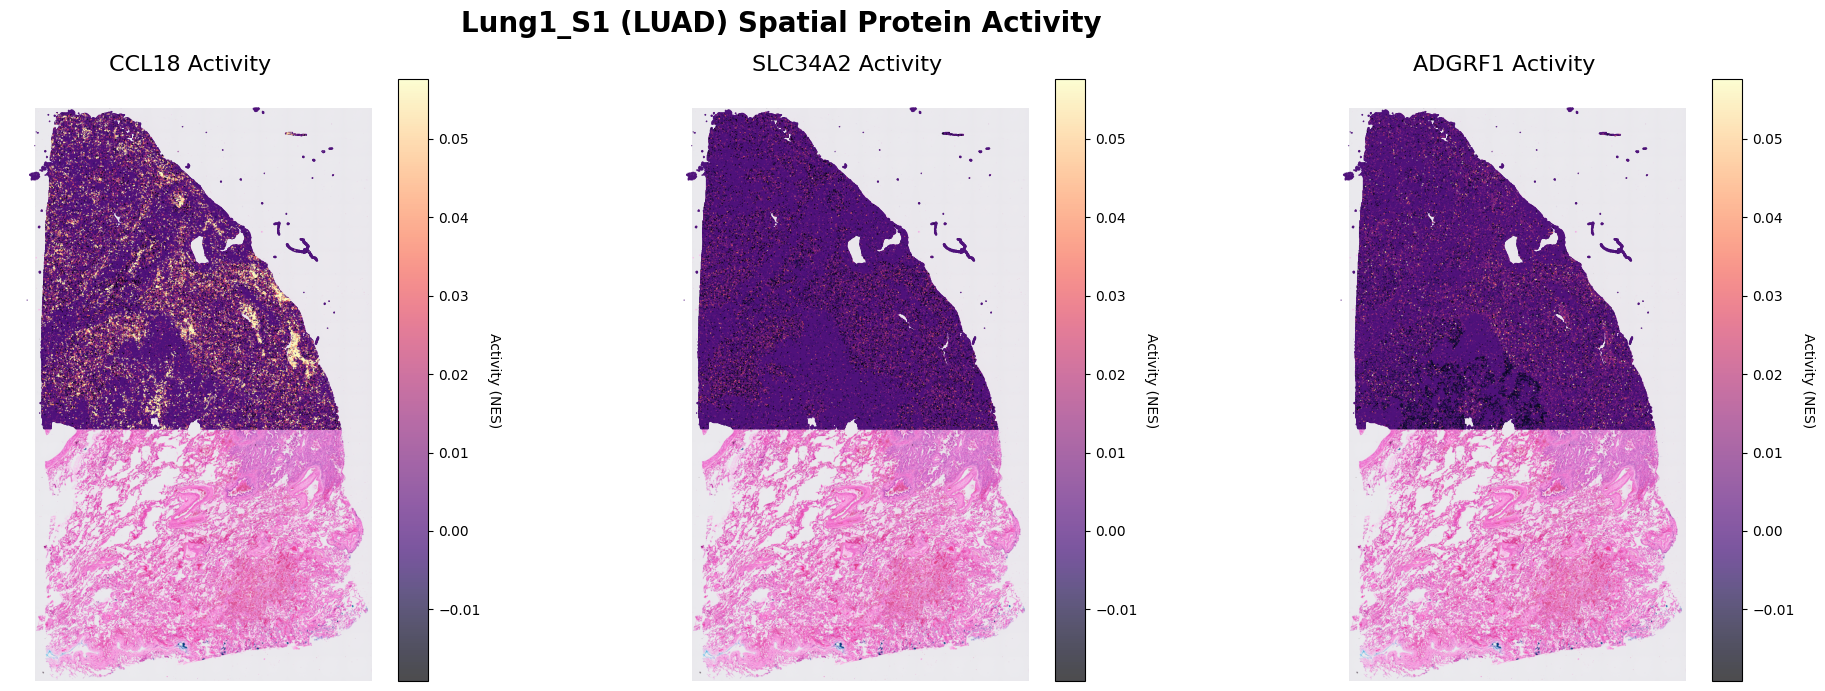


Processing Lung6_S2 (Fibrosis)...
Unified Scale set to: min=-0.0204, max=0.0679


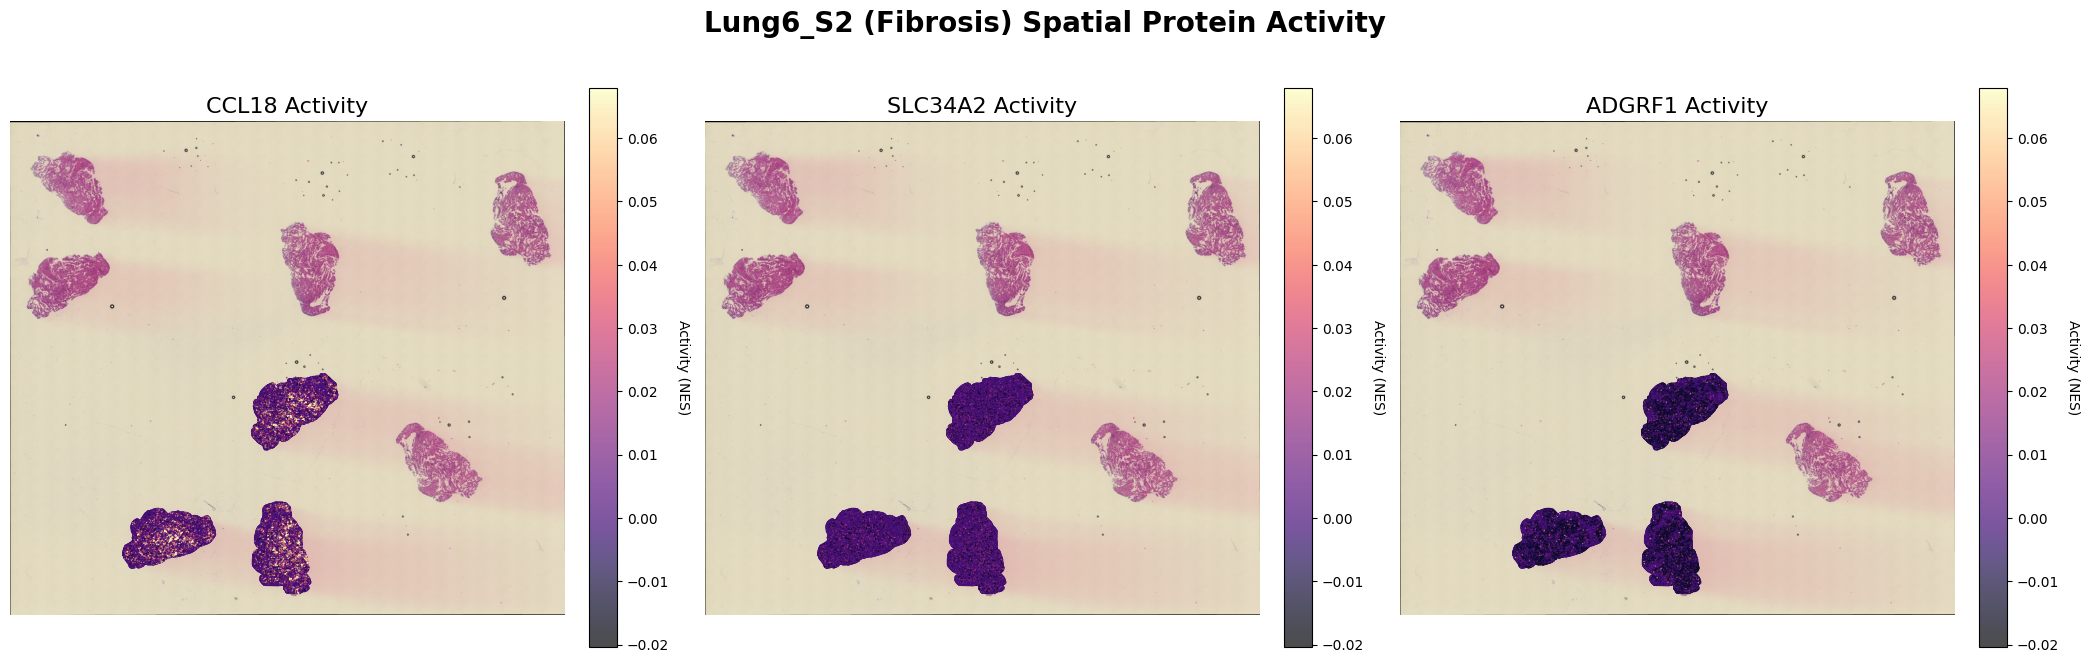

In [50]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np
import os

# ============================================================
# 1. YOUR SAMPLE DICTIONARY
# ============================================================
samples = {
    "Lung1_S1": {
        "disease": "LUAD",
        "h5ad": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample1/update_NES.h5ad",
        "spatial": "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/spatial/tissue_positions.parquet",
        "image": "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/spatial/tissue_hires_image.png",
        "scalefactors": "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/spatial/scalefactors_json.json",
    },
    "Lung6_S2": {
        "disease": "Fibrosis",
        "h5ad": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung6sample2/update_NES.h5ad",
        "spatial": "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung6/sample2/spatial/GSM8721366_LTx_008um_tissue_positions.parquet",
        "image": "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung6/sample2/spatial/GSM8721366_LTx_008um_tissue_hires_image.png",
        "scalefactors": "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung6/sample2/spatial/GSM8721366_LTx_008um_scalefactors_json.json",
    }
}

# The 3 proteins that tell your transition story
PROTEINS_TO_PLOT = ["CCL18", "SLC34A2", "ADGRF1"]

# ============================================================
# 2. PLOTTING FUNCTION
# ============================================================
def plot_spatial_protein_activity(sample_name, sample_info, proteins):
    print(f"\nProcessing {sample_name} ({sample_info['disease']})...")
    
    # Load AnnData (NES scores)
    adata = sc.read_h5ad(sample_info["h5ad"])
    
    # Load spatial coordinates (Parquet)
    pos_df = pd.read_parquet(sample_info["spatial"])
    if 'barcode' in pos_df.columns:
        pos_df = pos_df.set_index('barcode')
    
    # Align coordinates with the AnnData barcodes
    pos_df = pos_df.loc[adata.obs_names]
    
    # Load Image & Scalefactors
    img = plt.imread(sample_info["image"])
    with open(sample_info["scalefactors"]) as f:
        sf = json.load(f)
    scale_factor = sf.get("tissue_hires_scalef", 1.0)
    
    # Extract X, Y pixels and scale them to match the high-res image
    x_coords = pos_df["pxl_col_in_fullres"] * scale_factor
    y_coords = pos_df["pxl_row_in_fullres"] * scale_factor
    
    # Verify proteins exist in the sample
    valid_proteins = [p for p in proteins if p in adata.var_names]
    if not valid_proteins:
        print(f"Warning: None of the proteins found in {sample_name}.")
        return

    # --------------------------------------------------------
    # FIXED SCALE CALCULATION
    # Get scores for ALL proteins first to determine a global scale
    # --------------------------------------------------------
    all_scores = []
    for prot in valid_proteins:
        idx = adata.var_names.get_loc(prot)
        scores = adata.X[:, idx].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[:, idx].flatten()
        all_scores.append(scores)
    
    # Combine them and find the unified min and max (using 2% and 98% to avoid extreme single-spot outliers)
    combined_scores = np.concatenate(all_scores)
    unified_vmin, unified_vmax = np.percentile(combined_scores, [2, 98])
    print(f"Unified Scale set to: min={unified_vmin:.4f}, max={unified_vmax:.4f}")

    # Setup figure
    fig, axes = plt.subplots(1, len(valid_proteins), figsize=(7 * len(valid_proteins), 7))
    if len(valid_proteins) == 1: axes = [axes]
    
    fig.suptitle(f"{sample_name} ({sample_info['disease']}) Spatial Protein Activity", fontsize=20, fontweight="bold")
    
    for ax, prot, scores in zip(axes, valid_proteins, all_scores):
        # Background H&E Image
        ax.imshow(img)
        
        # Plot with the strictly enforced unified scale
        scatter = ax.scatter(
            x_coords, y_coords, 
            c=scores, 
            cmap='magma', 
            s=1.0, 
            alpha=0.7, 
            edgecolors='none',
            vmin=unified_vmin, vmax=unified_vmax 
        )
        
        ax.set_title(f"{prot} Activity", fontsize=16)
        ax.axis('off')
        
        # Colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Activity (NES)', rotation=270, labelpad=15)
        
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. RUN IT
# ============================================================
# Run for a LUAD sample
plot_spatial_protein_activity("Lung1_S1", samples["Lung1_S1"], PROTEINS_TO_PLOT)

# Run for a Fibrosis sample
plot_spatial_protein_activity("Lung6_S2", samples["Lung6_S2"], PROTEINS_TO_PLOT)

# cool graph

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# INPUT (TOP-200 integrated interactome)
# ============================================================
Interactome_SUVA_200 = "/shares/vasciaveo_lab/data/GBM_Project/Suva_GBM/Malignant_samples/Full_GRN/raw_suva_interactome_200.tsv"
df = pd.read_csv(Interactome_SUVA_200, sep="\t")

# ============================================================
# Robust column inference
# ============================================================
cols = {c.lower(): c for c in df.columns}
def pick(*cands):
    for c in cands:
        if c in cols:
            return cols[c]
    return None

src_col = pick("regulator", "tf", "source", "master_regulator", "mr")
tgt_col = pick("target", "gene", "targets")
lik_col = pick("likelihood", "score", "weight", "confidence", "mi")

if src_col is None or tgt_col is None:
    raise ValueError(f"Could not infer source/target columns. Columns: {list(df.columns)}")

if lik_col is None:
    df["_likelihood"] = 1.0
    lik_col = "_likelihood"

df[lik_col] = pd.to_numeric(df[lik_col], errors="coerce").fillna(0.0)

# ============================================================
# MR alias fix
# ============================================================
MR_ALIASES = {
    "NSD2": {"NSD2", "WHSC1", "MMSET"},
    "BRD2": {"BRD2"},
}

df["_SRC_UP"] = df[src_col].astype(str).str.upper()
df["_TGT"] = df[tgt_col].astype(str)

keep = df["_SRC_UP"].isin({x for s in MR_ALIASES.values() for x in s})
df_mr0 = df[keep].copy()

def canonical_mr(x):
    for canon, aliases in MR_ALIASES.items():
        if x in aliases:
            return canon
    return x

df_mr0["MR"] = df_mr0["_SRC_UP"].map(canonical_mr)
df_mr0["Target"] = df_mr0["_TGT"]

# collapse duplicates per MR-target (keep max likelihood)
df_mr = df_mr0.groupby(["MR", "Target"], as_index=False)[lik_col].max()

# ============================================================
# ENFORCE TOP-200 PER MR
# ============================================================
TOPN = 200
df_mr = (
    df_mr.sort_values(["MR", lik_col], ascending=[True, False])
         .groupby("MR", group_keys=False)
         .head(TOPN)
         .copy()
)

# ============================================================
# Target sets
# ============================================================
pivot = df_mr.pivot_table(index="Target", columns="MR", values=lik_col, aggfunc="max")
for mr in ["NSD2", "BRD2"]:
    if mr not in pivot.columns:
        pivot[mr] = np.nan

targets_nsd2 = set(pivot[~pivot["NSD2"].isna()].index)
targets_brd2 = set(pivot[~pivot["BRD2"].isna()].index)
common = targets_nsd2 & targets_brd2

nsd2_only = sorted(list(targets_nsd2 - common))   # alphabetical baseline (likelihood-free)
brd2_only = sorted(list(targets_brd2 - common))   # alphabetical baseline (likelihood-free)
common_list = sorted(list(common))                # alphabetical baseline (likelihood-free)

# ============================================================
# Bring hubs closer
# ============================================================
MR_SEP = 0.75
mr_pos = {"NSD2": (-MR_SEP / 2, 0.0), "BRD2": (MR_SEP / 2, 0.0)}

# ============================================================
# Build edges (darker)
# ============================================================
edges = []
for mr in ["NSD2", "BRD2"]:
    sub = df_mr[df_mr["MR"] == mr]
    for _, row in sub.iterrows():
        edges.append((mr, row["Target"], float(row[lik_col])))

edge_likes = np.array([e[2] for e in edges], dtype=float) if edges else np.array([1.0])
emin, emax = float(np.min(edge_likes)), float(np.max(edge_likes))

def edge_w(x):
    if emax == emin:
        return 0.70
    return 0.45 + 1.10 * ((x - emin) / (emax - emin))

EDGE_ALPHA = 0.30
EDGE_COLOR = "#4A4A4A"

# ============================================================
# NO-OVERLAP LABEL PLACEMENT (FULL CIRCLE, auto-grow radius)
# NOTE: This step does NOT use likelihood.
# ============================================================
LABEL_FONTSIZE = 7.0
HUB_EXCLUDE_R = 0.36

LABEL_PAD = 1.10
WX = 0.030 * (LABEL_FONTSIZE / 7.0)
WY = 0.060 * (LABEL_FONTSIZE / 7.0)

def label_box(x, y, text):
    half_w = LABEL_PAD * WX * max(1, len(text))
    half_h = LABEL_PAD * WY
    return (x - half_w, y - half_h, x + half_w, y + half_h)

def boxes_overlap(a, b):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    return not (ax1 < bx0 or bx1 < ax0 or ay1 < by0 or by1 < ay0)

def outside_hubs(x, y):
    for mr in ["NSD2", "BRD2"]:
        hx, hy = mr_pos[mr]
        if (x - hx)**2 + (y - hy)**2 < HUB_EXCLUDE_R**2:
            return False
    return True

def ang_dist(a, b):
    d = abs(a - b) % (2*np.pi)
    return min(d, 2*np.pi - d)

# closer labels
R_INNER = 0.92
R_OUTER_START = 1.38
R_OUTER_MAX   = 3.50   # <<< needs more room for 200; keep perfect circle, allow growth
PAD = 0.35

def build_candidates_full(r_inner, r_outer, n_rings, ang_step_deg):
    rings = np.linspace(r_inner, r_outer, n_rings)
    angles = np.deg2rad(np.arange(0, 360, ang_step_deg))
    cand = []
    for r in rings:
        for th in angles:
            x = r * np.cos(th)
            y = r * np.sin(th)
            if outside_hubs(x, y):
                cand.append((r, th, x, y))
    cand.sort(key=lambda t: t[0])  # closer-first
    return cand

TH_PREF = {"NSD2": np.pi, "BRD2": 0.0, "COMMON": np.pi/2}

def place_one_label(t, group, candidates, placed_boxes, used_idx, angle_weight, pos):
    best_i = None
    best_bb = None
    best_score = None
    best_xy = None
    pref = TH_PREF[group]

    for i, (r, th, x, y) in enumerate(candidates):
        if i in used_idx:
            continue

        bb = label_box(x, y, t)

        ok = True
        for pb in placed_boxes:
            if boxes_overlap(bb, pb):
                ok = False
                break
        if not ok:
            continue

        sc = r + angle_weight * ang_dist(th, pref)
        if (best_score is None) or (sc < best_score):
            best_score = sc
            best_i = i
            best_bb = bb
            best_xy = (x, y)

    if best_i is None:
        return False

    used_idx.add(best_i)
    placed_boxes.append(best_bb)
    pos[t] = best_xy
    return True

def try_place_all(r_inner, r_outer, n_rings, ang_step_deg):
    candidates = build_candidates_full(r_inner, r_outer, n_rings, ang_step_deg)
    angle_weight = 0.18 * r_outer

    pos_local = {}
    placed_boxes = []
    used_idx = set()

    for t in common_list:
        if not place_one_label(t, "COMMON", candidates, placed_boxes, used_idx, angle_weight, pos_local):
            return None
    for t in nsd2_only:
        if not place_one_label(t, "NSD2", candidates, placed_boxes, used_idx, angle_weight, pos_local):
            return None
    for t in brd2_only:
        if not place_one_label(t, "BRD2", candidates, placed_boxes, used_idx, angle_weight, pos_local):
            return None

    return pos_local

# Candidate density (more labels => more candidates)
N_RINGS = 34
ANG_STEP = 2.5

R_OUTER = R_OUTER_START
pos = None
while R_OUTER <= R_OUTER_MAX:
    placed = try_place_all(R_INNER, R_OUTER, N_RINGS, ANG_STEP)
    if placed is not None:
        pos = placed
        break
    R_OUTER += 0.05

if pos is None:
    raise RuntimeError(
        "Could not place all labels without overlap even after expanding the circle. "
        "Try: reduce LABEL_FONTSIZE to 6.5, or reduce LABEL_PAD to 1.05, "
        "or increase R_OUTER_MAX."
    )

pos_before_swap = dict(pos)

# ============================================================
# SWAP LABEL ASSIGNMENTS BY LIKELIHOOD (GEOMETRY UNCHANGED)
# ============================================================
def dist(p, q):
    return np.hypot(p[0] - q[0], p[1] - q[1])

nsd2_hub = mr_pos["NSD2"]
brd2_hub = mr_pos["BRD2"]
mid_hub  = ((nsd2_hub[0] + brd2_hub[0]) / 2, (nsd2_hub[1] + brd2_hub[1]) / 2)

def like_nsd2(t):
    v = pivot.loc[t, "NSD2"]
    return 0.0 if pd.isna(v) else float(v)

def like_brd2(t):
    v = pivot.loc[t, "BRD2"]
    return 0.0 if pd.isna(v) else float(v)

def like_common(t):
    return max(like_nsd2(t), like_brd2(t))

# slots = existing coordinates
nsd2_slots = [pos[t] for t in nsd2_only]
brd2_slots = [pos[t] for t in brd2_only]
comm_slots = [pos[t] for t in common_list]

# closest slots get highest-likelihood labels
nsd2_slots_sorted = sorted(nsd2_slots, key=lambda xy: dist(xy, nsd2_hub))
brd2_slots_sorted = sorted(brd2_slots, key=lambda xy: dist(xy, brd2_hub))
comm_slots_sorted = sorted(comm_slots, key=lambda xy: dist(xy, mid_hub))

nsd2_labels_sorted = sorted(nsd2_only, key=like_nsd2, reverse=True)
brd2_labels_sorted = sorted(brd2_only, key=like_brd2, reverse=True)
comm_labels_sorted = sorted(common_list, key=like_common, reverse=True)

new_pos = {}
for t, xy in zip(nsd2_labels_sorted, nsd2_slots_sorted):
    new_pos[t] = xy
for t, xy in zip(brd2_labels_sorted, brd2_slots_sorted):
    new_pos[t] = xy
for t, xy in zip(comm_labels_sorted, comm_slots_sorted):
    new_pos[t] = xy

pos = new_pos

moved = sum(1 for t in pos if pos[t] != pos_before_swap.get(t))
print(f"[Swap-by-likelihood] labels moved: {moved} / {len(pos)}")

# crop
lim = R_OUTER + PAD

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(7.4, 7.4))
ax.set_aspect("equal")
ax.axis("off")

# edges first
for mr, t, lk in edges:
    if t not in pos:
        continue
    x0, y0 = mr_pos[mr]
    x1, y1 = pos[t]
    ax.plot([x0, x1], [y0, y1],
            color=EDGE_COLOR,
            linewidth=edge_w(lk),
            alpha=EDGE_ALPHA,
            zorder=1)

# hubs
MR_NODE_SIZE = 2400
MR_FONT_SIZE = 16
for mr in ["NSD2", "BRD2"]:
    x, y = mr_pos[mr]
    ax.scatter([x], [y], s=MR_NODE_SIZE, c="red",
               edgecolors="black", linewidths=1.2, zorder=5)
    ax.text(x, y, mr, ha="center", va="center",
            fontsize=MR_FONT_SIZE, fontweight="bold",
            color="black", zorder=6)

# labels
for t in (common_list + nsd2_only + brd2_only):
    x, y = pos[t]
    ax.text(
        x, y, t,
        ha="center", va="center",
        fontsize=LABEL_FONTSIZE,
        fontweight=("bold" if t in common else "normal"),
        color="black",
        zorder=3
    )

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.text(
    0.5, -0.06,
    f"Targets(NSD2)={len(targets_nsd2)}   Targets(BRD2)={len(targets_brd2)}   Common={len(common)}",
    transform=ax.transAxes,
    ha="center", va="top",
    fontsize=11
)

plt.margins(0)
plt.tight_layout(pad=0)
plt.show()

SyntaxError: invalid non-printable character U+00A0 (728234015.py, line 16)

In [ ]:
#run only for scRNAseq, and only per tissue switch (GRN)
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import pyviper
from scipy import sparse as sp

def generate_metacells_final_v3(adata_path, out_dir, n_target=10):
    print(f"Loading data: {adata_path}")
    adata = sc.read_h5ad(adata_path)
    adata.var_names_make_unique()
    
    # ---------------------------------------------------------
    # NEW: Subsample to 20,000 cells for speed and ARACNe accuracy
    # ---------------------------------------------------------
    target_cells = 50000
    if adata.n_obs > target_cells:
        print(f"Dataset has {adata.n_obs} cells. Subsampling to {target_cells}...")
        sc.pp.subsample(adata, n_obs=target_cells, random_state=42)
    else:
        print(f"Dataset has {adata.n_obs} cells (no subsampling needed).")
    
    # Pre-processing for PCA space
    print("Normalizing and running PCA...")
    adata_raw = adata.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver='randomized')
    pyviper.pp.corr_distance(adata)

    all_metacells = []
    
    # TREAT ENTIRE ADATA AS ONE BATCH
    sub_adata = adata
    sub_raw = adata_raw
    n_cells = sub_adata.n_obs

    print(f"Processing single batch dataset with {n_cells} cells...")

    # If batch is large enough, try the optimized algorithm
    if n_cells > 60:
        try:
            pyviper.pp.repr_metacells(
                sub_adata,
                counts=sub_raw,
                pca_slot='X_pca',
                dist_slot='corr_dist',
                n_cells_per_metacell=n_target,
                perc_data_to_use=None,
                size=500,
                min_median_depth=None,
                perc_incl_data_reused=None,
                key_added="temp_mc",
                njobs=1,
                verbose=False
            )
            all_metacells.append(sub_adata.uns["temp_mc"])
        except Exception as e:
            print(f"Pyviper failed, using fallback: {e}")
            n_mc = max(1, int(n_cells / n_target))
            indices = np.arange(n_cells)
            groups = np.array_split(indices, n_mc)
            for i, g_idx in enumerate(groups):
                mc_val = np.sum(sub_raw.X[g_idx, :], axis=0)
                if sp.issparse(mc_val): mc_val = mc_val.toarray()
                df = pd.DataFrame(mc_val.reshape(1, -1), index=[f"mc_{i}"], columns=adata.var_names)
                all_metacells.append(df)
    else:
        n_mc = max(1, int(n_cells / n_target))
        indices = np.arange(n_cells)
        groups = np.array_split(indices, n_mc)
        for i, g_idx in enumerate(groups):
            mc_val = np.sum(sub_raw.X[g_idx, :], axis=0)
            if sp.issparse(mc_val): mc_val = mc_val.toarray()
            df = pd.DataFrame(mc_val.reshape(1, -1), index=[f"mc_{i}"], columns=adata.var_names)
            all_metacells.append(df)

    # Combine
    final_mc_df = pd.concat(all_metacells)
    
    # Final cleanup and normalization for ARACNe
    mc_adata = ad.AnnData(X=final_mc_df.values, 
                          obs=pd.DataFrame(index=final_mc_df.index), 
                          var=pd.DataFrame(index=final_mc_df.columns))
    sc.pp.normalize_total(mc_adata, target_sum=1e4)
    sc.pp.log1p(mc_adata)

    # ARACNe format: Transpose so Genes are Rows
    expr_df = pd.DataFrame(mc_adata.X, index=mc_adata.obs_names, columns=mc_adata.var_names).T

    out_path = os.path.join(out_dir, "lung1sample1v2.tsv")
    expr_df.to_csv(out_path, sep="\t")
    
    print(f"\n✅ SUCCESS!")
    print(f"Matrix: {expr_df.shape[0]} genes x {expr_df.shape[1]} metacells")
    print(f"Saved to: {out_path}")

if __name__ == "__main__":
    generate_metacells_final_v3(
        adata_path="/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/super_updated_again.h5ad",
        out_dir="/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD"
    )

Loading data: /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/super_updated_again.h5ad
Dataset has 447595 cells. Subsampling to 20000...
Normalizing and running PCA...


/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:216: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  8.08it/s]


Processing single batch dataset with 20000 cells...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 182.04it/s]
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in


✅ SUCCESS!
Matrix: 18054 genes x 500 metacells
Saved to: /shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/LUAD/lung1sample1.tsv


In [10]:
adata = sc.read_h5ad("/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/super_updated_again.h5ad")

In [12]:
adata.obs

,n_genes
s_008um_00301_00321-1,88
s_008um_00602_00290-1,51
s_008um_00515_00112-1,94
s_008um_00789_00234-1,91
s_008um_00526_00291-1,61
...,...
s_008um_00653_00166-1,221
s_008um_00353_00477-1,486
s_008um_00565_00244-1,381
s_008um_00373_00222-1,121


In [ ]:
#run only for scRNAseq, and only per tissue switch (GRN)
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import pyviper
from scipy import sparse as sp
from tqdm import tqdm

def generate_metacells_final_v3(adata_path, out_dir, n_target=10):
    print(f"Loading data: {adata_path}")
    adata = sc.read_h5ad(adata_path)
    adata.var_names_make_unique()
    
    # Pre-processing for PCA space
    print("Normalizing and running PCA...")
    adata_raw = adata.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver='randomized')
    pyviper.pp.corr_distance(adata)

    all_metacells = []
    
    # REMOVED: sample_batch iteration
    # TREAT ENTIRE ADATA AS ONE BATCH
    sub_adata = adata
    sub_raw = adata_raw
    n_cells = sub_adata.n_obs

    print(f"Processing single batch dataset with {n_cells} cells...")

    # If batch is large enough, try the optimized algorithm
    if n_cells > 60:
        try:
            pyviper.pp.repr_metacells(
                sub_adata,
                counts=sub_raw,
                pca_slot='X_pca',
                dist_slot='corr_dist',
                n_cells_per_metacell=n_target,
                perc_data_to_use=None,
                size=500,
                min_median_depth=None,
                perc_incl_data_reused=None,
                key_added="temp_mc",
                njobs=1,
                verbose=False
            )
            all_metacells.append(sub_adata.uns["temp_mc"])
        except Exception as e:
            print(f"Pyviper failed, using fallback: {e}")
            n_mc = max(1, int(n_cells / n_target))
            indices = np.arange(n_cells)
            groups = np.array_split(indices, n_mc)
            for i, g_idx in enumerate(groups):
                mc_val = np.sum(sub_raw.X[g_idx, :], axis=0)
                if sp.issparse(mc_val): mc_val = mc_val.toarray()
                df = pd.DataFrame(mc_val.reshape(1, -1), index=[f"mc_{i}"], columns=adata.var_names)
                all_metacells.append(df)
    else:
        n_mc = max(1, int(n_cells / n_target))
        indices = np.arange(n_cells)
        groups = np.array_split(indices, n_mc)
        for i, g_idx in enumerate(groups):
            mc_val = np.sum(sub_raw.X[g_idx, :], axis=0)
            if sp.issparse(mc_val): mc_val = mc_val.toarray()
            df = pd.DataFrame(mc_val.reshape(1, -1), index=[f"mc_{i}"], columns=adata.var_names)
            all_metacells.append(df)

    # Combine
    final_mc_df = pd.concat(all_metacells)
    
    # Final cleanup and normalization for ARACNe
    mc_adata = ad.AnnData(X=final_mc_df.values, 
                          obs=pd.DataFrame(index=final_mc_df.index), 
                          var=pd.DataFrame(index=final_mc_df.columns))
    sc.pp.normalize_total(mc_adata, target_sum=1e4)
    sc.pp.log1p(mc_adata)

    # ARACNe format: Transpose so Genes are Rows
    expr_df = pd.DataFrame(mc_adata.X, index=mc_adata.obs_names, columns=mc_adata.var_names).T

    # Fixed output name to match your current lung stromal context
    out_path = os.path.join(out_dir, "lung6sample2.tsv")
    expr_df.to_csv(out_path, sep="\t")
    
    print(f"\n✅ SUCCESS!")
    print(f"Matrix: {expr_df.shape[0]} genes x {expr_df.shape[1]} metacells")
    print(f"Saved to: {out_path}")

if __name__ == "__main__":
    generate_metacells_final_v3(
        adata_path="/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung6/sample2/binned_outputs/square_008um/super_updated_again.h5ad",
        out_dir="/shares/vasciaveo_lab/aarulselvan/arachne/novelGRNs/IPF"
    )

wsp


# 002um to 008um

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import OneHotEncoder

def bin_visium_hd_biologically_correct(root_sample_dir, factor=4):

    # Define paths
    h5_path = os.path.join(root_sample_dir, "binned_outputs/square_002um/filtered_feature_bc_matrix/slide2_2um_filtered_feature_bc_matrix.h5")
    parquet_path = os.path.join(root_sample_dir, "spatial/slide2_2um_tissue_positions.parquet")
    
    # 1. Load Data
    print(f"Loading {h5_path}...")
    adata = sc.read_10x_h5(h5_path)
    positions = pd.read_parquet(parquet_path).set_index('barcode')
    
    # 2. Align Parquet and H5
    positions = positions.loc[positions.index.intersection(adata.obs_names)]
    adata = adata[positions.index].copy()
    
    # 3. Create 8um Grid Indices (Biological Binning)
    # Using integer division // ensures 16 2um spots (4x4) map to 1 8um spot
    adata.obs['bin_row'] = (positions['array_row'] // factor).astype(int)
    adata.obs['bin_col'] = (positions['array_col'] // factor).astype(int)
    adata.obs['bin_id'] = adata.obs['bin_row'].astype(str) + "_" + adata.obs['bin_col'].astype(str)
    
    # 4. Fast Sparse Aggregation
    print("Aggregating counts...")
    adata.obs['bin_id'] = adata.obs['bin_id'].astype('category')
    encoder = OneHotEncoder()
    weights = encoder.fit_transform(adata.obs['bin_id'].cat.codes.values.reshape(-1, 1))
    
    # Sum the RNA counts to preserve total transcript molecules
    new_X = (weights.T @ adata.X)
    
    # 5. Build 8um AnnData Object
    new_obs = adata.obs.groupby('bin_id', observed=True).agg({
        'bin_row': 'first',
        'bin_col': 'first'
    })
    new_obs = new_obs.loc[adata.obs['bin_id'].cat.categories]
    
    adata_8um = sc.AnnData(X=new_X, obs=new_obs, var=adata.var, dtype='float32')
    
    # 6. Map back to pixels for visualization (average pixel position of the 2um spots)
    positions['bin_id'] = adata.obs['bin_id']
    pixel_coords = positions.groupby('bin_id')[['pxl_col_in_fullres', 'pxl_row_in_fullres']].mean()
    adata_8um.obsm['spatial'] = pixel_coords.loc[adata_8um.obs_names].values
    
    # 7. ARACNe Prep: Swap to Gene Symbols
    # This prevents the "zero edges" error by matching your TF list
    if 'feature_name' in adata_8um.var.columns:
        adata_8um.var_names = adata_8um.var['feature_name'].astype(str)
    
    adata_8um.var_names_make_unique()
    
    return adata_8um


root_dir = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/"
save_path = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/sample2_8um_final.h5ad"

adata_8um = bin_visium_hd_biologically_correct(root_dir)

adata_8um.write_h5ad(save_path)

print(f"Success! Final Count: {adata_8um.n_obs}")
print(f"File saved to: {save_path}")

Loading /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/binned_outputs/square_002um/filtered_feature_bc_matrix/slide2_2um_filtered_feature_bc_matrix.h5...


/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Aggregating counts...


/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/aarulselvan/miniconda3/envs/myenv/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


✅ Success! Final Count: 223536
💾 File saved to: /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/sample2_8um_final.h5ad


# altered Visium HD -> three groups

In [50]:
import scanpy as sc
import anndata as ad
import os
import pandas as pd
import numpy as np
import singlecellexperiment as sce
import celldex
import singler
from scipy import sparse as sp

# --- CONFIGURATION ---
# Point this to the .h5ad file you just created
INPUT_H5AD = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/sample2_8um_final.h5ad"
OUT_DIR    = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results"
os.makedirs(OUT_DIR, exist_ok=True)

sample_id = "lung5_sample2_8um"
THREADS = 32 

# --- DATA LOADING ---
print(f"Loading binned h5ad: {INPUT_H5AD}")
sample_adata = sc.read_h5ad(INPUT_H5AD)

# Ensure var_names are symbols (the previous script should have handled this, but good to be safe)
sample_adata.var_names_make_unique()

# --- QC METRICS ---
# Note: Since this is 8um binned data, we calculate metrics based on the summed counts
sample_adata.var["mt"] = sample_adata.var_names.str.startswith("MT-")
sample_adata.var["ribo"] = sample_adata.var_names.str.startswith(("RPS", "RPL"))
sample_adata.var["hb"] = sample_adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(sample_adata, qc_vars=["mt", "ribo", "hb"], percent_top=[20], inplace=True, log1p=True)

# Filtering (adjusted for 8um bins)
sample_adata = sample_adata[sample_adata.obs.pct_counts_mt <= 20].copy()
sc.pp.filter_cells(sample_adata, min_genes=100) 
sc.pp.filter_genes(sample_adata, min_cells=3)

# --- ANNOTATION WITH SINGLER ---
print(f"Converting to SingleCellExperiment...")
# Convert to SCE for SingleR
sce_obj = sce.SingleCellExperiment.from_anndata(sample_adata)
counts_mat = sce_obj.assay("X")

if sp.issparse(counts_mat):
    counts_mat = counts_mat.tocsr()
    counts_mat.sort_indices()

genes = list(sce_obj.row_data.row_names)

print("Fetching reference data...")
ref_data = celldex.fetch_reference(name="blueprint_encode", version="2024-02-26", realize_assays=True)
ref_labels = list(ref_data.get_column_data().column("label.main"))

print(f"Running SingleR annotation on {sample_adata.n_obs} bins using {THREADS} threads...")

results = singler.annotate_single(
    test_data     = counts_mat,
    test_features = genes,
    ref_data      = ref_data,
    ref_labels    = ref_labels,
    num_threads   = THREADS
)

sample_adata.obs["cell_type"] = results.column("best")

# --- CATEGORICAL EXTRACTION ---

cell_groups = {
    "IMMUNE": [
        "T cells", "B cells", "NK cells", "Monocytes", "Macrophages", 
        "Dendritic cells", "Mast cells", "Neutrophils",
        "B-cells", "DC", "CD4+ T-cells", "CD8+ T-cells", 
        "Eosinophils", "HSC", "Erythrocytes"
    ],
    "EPITHELIAL": [
        "Epithelial cells", "AT1 / AT2", "Basal cells", 
        "Secretory cells", "Tumor epithelial", "Club cells",
        "Keratinocytes", "Melanocytes"
    ],
    "STROMAL": [
        "Fibroblasts", "Endothelial cells", "Pericytes", 
        "Smooth muscle cells", "Mesenchymal stromal cells",
        "Adipocytes", "Skeletal muscle", "Mesangial cells", 
        "Smooth muscle", "Chondrocytes", "Myocytes"
    ]
}

sample_adata.obs['broad_category'] = 'Other'
for category, cell_list in cell_groups.items():
    sample_adata.obs.loc[sample_adata.obs['cell_type'].isin(cell_list), 'broad_category'] = category

# Summary and saving
summary_data = []
print("\n--- Saving Categories ---")

for group_name in cell_groups.keys():
    subset = sample_adata[sample_adata.obs['broad_category'] == group_name].copy()
    count = subset.n_obs
    pct = (count / sample_adata.n_obs) * 100
    summary_data.append({"Category": group_name, "Count": count, "Percentage": f"{pct:.2f}%"})
    
    if count > 0:
        out_path = os.path.join(OUT_DIR, f"adata_{sample_id}_{group_name.lower()}.h5ad")
        subset.write(out_path)
        print(f"Saved {group_name} to {out_path}")

other_count = (sample_adata.obs['broad_category'] == 'Other').sum()
summary_data.append({"Category": "OTHER", "Count": other_count, "Percentage": f"{(other_count/sample_adata.n_obs)*100:.2f}%"})

print("\n--- Final Statistics ---")
print(pd.DataFrame(summary_data).to_string(index=False))

Loading binned h5ad: /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/sample2_8um_final.h5ad
Converting to SingleCellExperiment...
Fetching reference data...
Running SingleR annotation on 93862 bins using 32 threads...

--- Saving Categories ---
Saved IMMUNE to /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results/adata_lung5_sample2_8um_immune.h5ad
Saved EPITHELIAL to /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results/adata_lung5_sample2_8um_epithelial.h5ad
Saved STROMAL to /shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results/adata_lung5_sample2_8um_stromal.h5ad

--- Final Statistics ---
  Category  Count Percentage
    IMMUNE   8021      8.55%
EPITHELIAL  45016     47.96%
   STROMAL  36363     38.74%
     OTHER   4462      4.75%


In [ ]:
import scanpy as sc
import os

# ============================================================================
# CONFIGURATION - EDIT THESE PATHS
# ============================================================================

# Input: Three category-specific h5ad files (from SingleR pipeline)
input_epithelial = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results/adata_lung5_sample2_8um_epithelial.h5ad"
input_stromal = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results/adata_lung5_sample2_8um_stromal.h5ad"
input_immune = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results/adata_lung5_sample2_8um_immune.h5ad"

# Output: Combined h5ad file
output_combined = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung5/sample2/modified_pipeline_results/adata_lung5_sample2_square008um_COMBINED.h5ad"

# Sample identifier (just for logging, NOT added to barcodes)
sample_id = "lung5_sample2"

# ============================================================================
# CONCATENATION (NO SingleR, NO barcode prefixes)
# ============================================================================

print("="*80)
print("H5AD CONCATENATION (Epithelial + Stromal + Immune)")
print("="*80)

# Load files
print(f"\n📂 Loading files...")
print(f"   Epithelial: {input_epithelial}")
adata_epi = sc.read_h5ad(input_epithelial)
print(f"      ✅ {adata_epi.n_obs} cells, {adata_epi.n_vars} genes")

print(f"   Stromal: {input_stromal}")
adata_str = sc.read_h5ad(input_stromal)
print(f"      ✅ {adata_str.n_obs} cells, {adata_str.n_vars} genes")

print(f"   Immune: {input_immune}")
adata_imm = sc.read_h5ad(input_immune)
print(f"      ✅ {adata_imm.n_obs} cells, {adata_imm.n_vars} genes")

# Concatenate WITHOUT modifying barcodes
print(f"\n🔗 Concatenating...")
adata_combined = sc.concat([adata_epi, adata_str, adata_imm], axis=0, join='outer')

print(f"   ✅ Combined: {adata_combined.n_obs} cells, {adata_combined.n_vars} genes")

# Verify barcodes
print(f"\n🔍 Barcode check:")
print(f"   First 3 epithelial: {list(adata_epi.obs_names[:3])}")
print(f"   First 3 in combined: {list(adata_combined.obs_names[:3])}")
print(f"   ✅ Barcodes preserved (no prefixes added)")

# Save
print(f"\n💾 Saving combined file...")
print(f"   Output: {output_combined}")
adata_combined.write_h5ad(output_combined)

print("\n" + "="*80)
print("✅ COMPLETE!")
print("="*80)
print(f"Sample: {sample_id}")
print(f"Total cells: {adata_combined.n_obs}")
print(f"Total genes: {adata_combined.n_vars}")
print(f"Cell type breakdown:")
print(adata_combined.obs['broad_category'].value_counts())

In [ ]:
import os
import scanpy as sc
import pandas as pd
import anndata as ad
from pathlib import Path

# =============================================================================
# !!! EDIT THESE 4 LINES FOR EACH DATASET !!!
# =============================================================================
INPUT_PATH  = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/filtered_feature_bc_matrix"
SAMPLE_ID   = "lung1_sample1_square008um"
FILE_TYPE   = "standard_10x"  # "dense_txt", "dense_tsv", "dense_csv", "standard_10x", or "custom_10x"
OUTPUT_H5AD = "/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung1/sample1_tumor/binned_outputs/square_008um/super_updated.h5ad"

# =============================================================================
# FLEXIBLE LOAD LOGIC
# =============================================================================
def load_data(path_str, fmt):
    path = Path(path_str)
    print(f"[{SAMPLE_ID}] Loading {fmt} from: {path}...")
    
    try:
        if fmt == "dense_txt":
            adata = sc.read_text(path, delimiter='\t').T
            
        elif fmt == "dense_csv":
            adata = sc.read_csv(path)
            
        elif fmt == "dense_tsv":
            df = pd.read_csv(path, sep='\t', index_col=0)
            adata = ad.AnnData(df.T)
            
        elif fmt == "standard_10x":
            adata = sc.read_10x_mtx(path, var_names='gene_symbols', cache=False)
            
        elif fmt == "custom_10x":
            mtx_files = list(path.glob("*matrix*.mtx*"))
            if not mtx_files: 
                available = [f.name for f in path.glob("*")]
                raise FileNotFoundError(f"No .mtx found. Folder contains: {available}")
            
            print(f"   -> Found matrix: {mtx_files[0].name}")
            adata = sc.read_mtx(mtx_files[0]).T
            
            # Load features/genes
            feat_files = list(path.glob("*features*.tsv*")) or list(path.glob("*genes*.tsv*"))
            if feat_files:
                print(f"   -> Found features: {feat_files[0].name}")
                genes = pd.read_csv(feat_files[0], sep='\t', header=None)
                adata.var_names = genes[1].values if genes.shape[1] > 1 else genes[0].values
            
            # Load barcodes
            bar_files = list(path.glob("*barcodes*.tsv*"))
            if bar_files:
                print(f"   -> Found barcodes: {bar_files[0].name}")
                barcodes = pd.read_csv(bar_files[0], sep='\t', header=None)
                adata.obs_names = barcodes[0].values
                
        else:
            raise ValueError(f"Invalid FILE_TYPE: {fmt}")
        
        # Make names unique
        adata.var_names_make_unique()
        adata.obs_names_make_unique()
        
        print(f"   ✅ Loaded: {adata.n_obs} cells, {adata.n_vars} genes")
        return adata
        
    except Exception as e:
        print(f"❌ ERROR LOADING DATA: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# =============================================================================
# MAIN
# =============================================================================
print("="*80)
print(f"Converting to h5ad: {SAMPLE_ID}")
print("="*80)

# Load data
adata = load_data(INPUT_PATH, FILE_TYPE)

if adata is None:
    print("❌ Failed to load data. Exiting.")
    exit(1)

print(f"\n📋 Initial data:")
print(f"   Shape: {adata.shape}")

# =============================================================================
# PREPROCESSING
# =============================================================================
print(f"\n🔧 Preprocessing...")

# Filter cells and genes
print(f"   Filtering cells (min_genes=200)...")
sc.pp.filter_cells(adata, min_genes=200)
print(f"      -> {adata.n_obs} cells remaining")

print(f"   Filtering genes (min_cells=3)...")
sc.pp.filter_genes(adata, min_cells=3)
print(f"      -> {adata.n_vars} genes remaining")

# Normalization
print(f"   Normalizing to 10,000 counts per cell...")
sc.pp.normalize_total(adata, target_sum=1e4)

print(f"   Log1p transformation...")
sc.pp.log1p(adata)

# Highly variable genes
print(f"   Finding highly variable genes (top 2000)...")
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
hvg_list = adata.var_names[adata.var['highly_variable']].tolist()
print(f"      -> {len(hvg_list)} HVGs identified")

# =============================================================================
# SAVE
# =============================================================================
print(f"\n📋 Final data:")
print(f"   Shape: {adata.shape}")
print(f"   First 5 barcodes: {list(adata.obs_names[:5])}")
print(f"   First 5 genes: {list(adata.var_names[:5])}")
print(f"   Matrix type: {type(adata.X).__name__}")

# Create output directory if needed
os.makedirs(os.path.dirname(OUTPUT_H5AD), exist_ok=True)

# Save as h5ad
print(f"\n💾 Saving to: {OUTPUT_H5AD}")
adata.write_h5ad(OUTPUT_H5AD)

print("\n" + "="*80)
print("✅ CONVERSION COMPLETE!")
print("="*80)
print(f"Sample: {SAMPLE_ID}")
print(f"Output: {OUTPUT_H5AD}")
print(f"Cells: {adata.n_obs}")
print(f"Genes: {adata.n_vars}")
print(f"HVGs: {len(hvg_list)}")

In [ ]:
import scanpy as sc
import pandas as pd
import pyviper
import time

# ============================================================================
# MANUAL INPUT - EDIT THESE PATHS
# ============================================================================

# Input: Combined h5ad file (WITHOUT barcode prefixes)
input_h5ad = '/shares/vasciaveo_lab/aarulselvan/arachne/datasets/lung/lung6/sample1/binned_outputs/square_008um/super_updated_again.h5ad'

# Output: Where to save the protein activity h5ad
output_h5ad = '/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung6sample1/update_NES.h5ad'

# Networks
network_path_stromal = "/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung_again/stromal/consolidated-net_defaultid.tsv"
network_path_epithelial = "/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung_again/epithelial/consolidated-net_defaultid.tsv"
network_path_immune = "/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung_again/immune/consolidated-net_defaultid.tsv"

# ============================================================================
# RUN metaVIPER
# ============================================================================

print("="*80)
print("metaVIPER: Multi-Network Protein Activity Inference")
print("="*80)
start_time = time.time()

# 1) Load data
print(f"\n📂 Loading data from:")
print(f"   {input_h5ad}")
data_lungadata = sc.read_h5ad(input_h5ad)
print(f"   ✅ Loaded: {data_lungadata.n_obs} cells, {data_lungadata.n_vars} genes")
print(f"   📋 First 5 barcodes: {list(data_lungadata.obs_names[:5])}")

# 2) Load networks
print(f"\n📚 Loading networks...")
df_stromal = pd.read_csv(network_path_stromal, sep="\t")
regulon_stromal = pyviper.pp.aracne3_to_regulon(net_file=None, net_df=df_stromal, regul_size=100)
network_interactome_stromal = pyviper.Interactome("lung_stromal", regulon_stromal)

df_epithelial = pd.read_csv(network_path_epithelial, sep="\t")
regulon_epithelial = pyviper.pp.aracne3_to_regulon(net_file=None, net_df=df_epithelial, regul_size=100)
network_interactome_epithelial = pyviper.Interactome("lung_epithelial", regulon_epithelial)

df_immune = pd.read_csv(network_path_immune, sep="\t")
regulon_immune = pyviper.pp.aracne3_to_regulon(net_file=None, net_df=df_immune, regul_size=100)
network_interactome_immune = pyviper.Interactome("lung_immune", regulon_immune)

print(f"   ✅ Loaded 3 networks")

# 3) Filter networks to match genes (CRITICAL - no warnings, faster)
print(f"\n🔧 Filtering networks to match expression data...")
network_interactome_stromal.filter_targets(data_lungadata.var_names)
network_interactome_epithelial.filter_targets(data_lungadata.var_names)
network_interactome_immune.filter_targets(data_lungadata.var_names)
print(f"   ✅ Networks filtered")

# 4) Run metaVIPER
print(f"\n🚀 Running metaVIPER with 32 cores...")
viper_start = time.time()

lung_nes_meta = pyviper.viper(
    gex_data=data_lungadata,
    interactome=[network_interactome_stromal, 
                 network_interactome_epithelial,
                 network_interactome_immune],
    enrichment="area",
    eset_filter=False,
    njobs=32,
    verbose=True
)

viper_time = time.time() - viper_start
print(f"\n✅ metaVIPER completed in {viper_time/60:.2f} minutes")

# 5) Save as h5ad (NO barcode manipulation!)
print(f"\n💾 Saving results...")
print(f"   Output: {output_h5ad}")
print(f"   Format: h5ad")
print(f"   Proteins: {lung_nes_meta.shape[1]}")
print(f"   Cells: {lung_nes_meta.shape[0]}")

# Verify barcodes match input
print(f"\n🔍 Barcode verification:")
print(f"   Input barcodes (first 3): {list(data_lungadata.obs_names[:3])}")
print(f"   Output barcodes (first 3): {list(lung_nes_meta.obs_names[:3])}")

if list(data_lungadata.obs_names) == list(lung_nes_meta.obs_names):
    print(f"   ✅ Barcodes match perfectly!")
else:
    print(f"   ⚠️  WARNING: Barcodes don't match!")

# Save
lung_nes_meta.write_h5ad(output_h5ad)

total_time = time.time() - start_time

print("\n" + "="*80)
print("✅ COMPLETE!")
print("="*80)
print(f"Total runtime: {total_time/60:.2f} minutes")
print(f"Output saved to: {output_h5ad}")
print(f"Number of proteins: {lung_nes_meta.shape[1]}")
print(f"Number of cells: {lung_nes_meta.shape[0]}")

In [1]:
print("sp")

sp


In [2]:
import scanpy as sc
import numpy as np
from scipy.stats import norm
import pandas as pd

# --- CONFIG ---
input_file = "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample1/update_NES.h5ad"
output_file = "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample1/update2_mLog10.h5ad"

# 1. Load Data
print(f"📂 Loading: {input_file}")
vp_data = sc.read_h5ad(input_file)

# Ensure data is dense for the math operations
if hasattr(vp_data.X, "toarray"):
    vp_data.X = vp_data.X.toarray()

# 2. Explicit Transform
print("🧪 Applying mLog10 transform...")
# Note: This highlights significantly activated regulators (Right Tail)
vp_data.layers['mLog10'] = -1 * np.log10(norm.sf(vp_data.X))

# 3. Analyze Transform
# We use .values if it's a layer to get the underlying numpy array
mlog_values = vp_data.layers['mLog10']

# Handle potential inf/nan for counting
valid_values = mlog_values[np.isfinite(mlog_values)]

count_gt_2 = np.sum(valid_values > 1)
count_lt_2 = np.sum(valid_values < 1)

print("\n📊 Statistical Summary:")
print(f"   - Values > 2 (Highly Significant): {count_gt_2:,}")
print(f"   - Values < 2:                      {count_lt_2:,}")

# 4. Save
print(f"\n💾 Saving to: {output_file}")
vp_data.write_h5ad(output_file)

# 5. Verify with 10x10 print
df_10x10 = pd.DataFrame(
    vp_data.layers['mLog10'][:10, :10], 
    index=vp_data.obs_names[:10], 
    columns=vp_data.var_names[:10]
)
print("\n--- 10x10 Sample Output ---")
print(df_10x10)

📂 Loading: /shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample1/update_NES.h5ad
🧪 Applying mLog10 transform...

📊 Statistical Summary:
   - Values > 2 (Highly Significant): 35,093
   - Values < 2:                      3,159,985,607

💾 Saving to: /shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample1/update2_mLog10.h5ad

--- 10x10 Sample Output ---
                           AAMP      AATF     ABCA1    ABCA12     ABCA3  \
s_008um_00000_00175-1  0.278590  0.300351  0.299938  0.300940  0.300564   
s_008um_00000_00179-1  0.317221  0.300770  0.299596  0.300912  0.300418   
s_008um_00000_00202-1  0.282639  0.293418  0.325144  0.326811  0.300008   
s_008um_00000_00251-1  0.320975  0.300750  0.300815  0.300993  0.300838   
s_008um_00000_00283-1  0.312205  0.300577  0.301191  0.300970  0.300720   
s_008um_00000_00333-1  0.299690  0.300857  0.300751  0.301007  0.300911   
s_008um_00000_00392-1  0.306384  0.307298  0.299404  0.300896  0.300336   
s_008um_00000_00410-1  0

In [3]:
import scanpy as sc
import numpy as np

# --- CONFIG ---
input_file = "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample1/update2_mLog10.h5ad"

# 1. Load Data
vp_data = sc.read_h5ad(input_file)

# Ensure dense matrix for easy indexing
if hasattr(vp_data.layers['mLog10'], "toarray"):
    vp_data.layers['mLog10'] = vp_data.layers['mLog10'].toarray()

# Flatten values
vals = vp_data.layers['mLog10'].flatten()
vals = vals[np.isfinite(vals)]  # remove NaNs / infs

# 2. Thresholds to check
thresholds = [0.1, 0.25, 0.5, 0.75, 1, 2]

# 3. Print counts above/below each threshold
for t in thresholds:
    above = np.sum(vals > t)
    below = np.sum(vals < t)
    print(f"Threshold {t}: Values > {t} = {above:,}, Values < {t} = {below:,}")


Threshold 0.1: Values > 0.1 = 3,159,720,498, Values < 0.1 = 300,202
Threshold 0.25: Values > 0.25 = 2,959,276,201, Values < 0.25 = 200,744,499
Threshold 0.5: Values > 0.5 = 4,374,636, Values < 0.5 = 3,155,646,064
Threshold 0.75: Values > 0.75 = 226,680, Values < 0.75 = 3,159,794,020
Threshold 1: Values > 1 = 35,093, Values < 1 = 3,159,985,607
Threshold 2: Values > 2 = 390, Values < 2 = 3,160,020,310


In [2]:
import scanpy as sc

# Use your actual sample dictionary with paths
samples = {
    "Lung1_S1": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample1/update_NES.h5ad",
    "Lung1_S2": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung1sample2/update_NES.h5ad",
    "Lung2_S1": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung2sample1/update_NES.h5ad",
    "Lung3_S1": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung3sample1/update_NES.h5ad",
    "Lung6_S1": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung6sample1/update_NES.h5ad",
    "Lung6_S2": "/shares/vasciaveo_lab/aarulselvan/arachne/NEWPAtables/lung6sample2/update_NES.h5ad",
}

total_spots = 0

print(f"{'Sample':<12} | {'Spots (Observations)':<20}")
print("-" * 35)

for name, path in samples.items():
    # Loading backed=True makes this run almost instantly without using RAM
    adata = sc.read_h5ad(path, backed='r')
    n_spots = adata.n_obs
    total_spots += n_spots
    print(f"{name:<12} | {n_spots:<20,}")

print("-" * 35)
print(f"{'TOTAL':<12} | {total_spots:<20,}")

Sample       | Spots (Observations)
-----------------------------------
Lung1_S1     | 447,595             
Lung1_S2     | 420,236             
Lung2_S1     | 616,510             
Lung3_S1     | 605,431             
Lung6_S1     | 311,885             
Lung6_S2     | 133,872             
-----------------------------------
TOTAL        | 2,535,529           


In [4]:
import pandas as pd

# Path to the specific Epithelial GRN
GRN_PATH = "/shares/vasciaveo_lab/data/adhiban_scRNAseq_datasets/lung/lung_reimagined/epithelial/GRN_epithelial/consolidated-net_defaultid.tsv"

print("Loading Epithelial GRN...")
# We use low_memory=False because these ARACNe files can be quite large
df = pd.read_csv(GRN_PATH, sep="\t", low_memory=False)

# Clean headers (handling the .values suffix if present)
df.columns = [c.lower().replace(".values", "") for c in df.columns]

# Edge calculations
total_edges = len(df)
unique_regulators = df.iloc[:, 0].nunique()
unique_targets = df.iloc[:, 1].nunique()

print(f"\n{'='*40}")
print("EPITHELIAL GRN STATS")
print(f"{'='*40}")
print(f"Total Edges:           {total_edges:,}")
print(f"Unique Regulators:     {unique_regulators:,}")
print(f"Unique Targets:        {unique_targets:,}")
print(f"Average Edges per Reg: {total_edges / unique_regulators:.2f}")
print(f"{'='*40}")

# Preview the top 5 edges
print("\nTop 5 Edges (Preview):")
print(df.head())

Loading Epithelial GRN...

EPITHELIAL GRN STATS
Total Edges:           7,139,948
Unique Regulators:     2,366
Unique Targets:        21,032
Average Edges per Reg: 3017.73

Top 5 Edges (Preview):
  regulator   target        mi       scc  count     log.p
0     ZZEF1   ZSWIM3  0.020370 -0.043618      1  -3.94434
1     ZZEF1  ZRSR2P1  0.001152  0.041811      1  -3.94434
2     ZZEF1     ZPBP  0.005418  0.142256      4 -18.99250
3     ZZEF1      ZP2  0.001569  0.053817      1  -3.94434
4     ZZEF1      ZP1  0.002049  0.065535      1  -3.94434
